# V12: Multi-GNN — Scale-Free Graph + ROS Pipeline + Optuna HPO · 5-Fold CV

**New in V12 over V11:**
- **Scale-Free Analysis** (Cell 4a): Proves the original bipartite graph is NOT scale-free using log-log regression R² comparison + KS test
- **Scale-Free Graph** (Cell 4b): Barabasi-Albert rewiring adds `Patient→cooccurs→Patient` layer with γ≈3; Gene↔Patient edges unchanged
- **ROS Pipeline** (Pipeline D): Random Over-Sampling — no interpolation artefacts, binary-safe for gene mutation columns
- **ROS + Scale-Free Pipeline** (Pipeline E): Combined BA graph + ROS balancing
- All V11 improvements retained: sqrt-penalty · G-mean threshold · 5-Fold CV · DAHGNN

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random, copy, warnings

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

from torch_geometric.data import HeteroData
from torch_geometric.nn import (GATv2Conv, Linear, HGTConv,
                                 RGCNConv, HypergraphConv, ChebConv)

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from imblearn.over_sampling import SMOTENC
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

import os

def set_seed(seed=42):
    """Full determinism:
    - Python / NumPy / PyTorch RNGs
    - cuDNN deterministic algorithms (no non-deterministic scatter ops)
    - PYTHONHASHSEED for dict/set ordering
    NOTE: cudnn.deterministic=True adds ~10-20% training overhead.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True   # no non-det cuDNN kernels
    torch.backends.cudnn.benchmark     = False  # disable auto-tuner (picks diff algo each run)

set_seed(42)

N_TRIALS   = 30    # Optuna TPE trials per model×pipeline
N_FOLDS    = 5     # stratified CV folds
MAX_EPOCHS = 200
PATIENCE   = 20

/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libnvToolsExt.so.1: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "


Using device: cuda
GPU: NVIDIA GeForce RTX 3050


## 2. Load Data

In [2]:
tcga_df = pd.read_csv('../../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
                'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']
NUM_GENES = len(gene_columns)

print("TCGA:", tcga_df.shape, "  Grade dist:", dict(tcga_df['Grade'].value_counts()))
print("CGGA:", cgga_df.shape, "  Grade dist:", dict(cgga_df['Grade'].value_counts()))

TCGA: (839, 24)   Grade dist: {0: 487, 1: 352}
CGGA: (286, 24)   Grade dist: {0: 184, 1: 102}


## 3. Splits — 20% held-out test; remaining 80% used for HPO + 5-Fold CV

In [3]:
# Hold out 20% as final test set (never seen during HPO or CV)
train_val_df, test_df = train_test_split(
    tcga_df, test_size=0.2, stratify=tcga_df['Grade'], random_state=42)

# Further split train_val for Optuna HPO warmup (val graph used only in HPO phase)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df['Grade'], random_state=42)

print(f"Train(HPO)={len(train_df)}  Val(HPO)={len(val_df)}  "
      f"TrainVal(CV)={len(train_val_df)}  Test={len(test_df)}")
print("Train Grade dist:", dict(train_df['Grade'].value_counts()))
print("Test  Grade dist:", dict(test_df['Grade'].value_counts()))

Train(HPO)=536  Val(HPO)=135  TrainVal(CV)=671  Test=168
Train Grade dist: {0: 311, 1: 225}
Test  Grade dist: {0: 98, 1: 70}


## 4. Graph Construction

In [4]:
_PP_CACHE: dict = {}


def construct_bipartite_heterograph(df: pd.DataFrame) -> HeteroData:
    graph = HeteroData()
    scaler    = StandardScaler()
    age_norm  = scaler.fit_transform(df[['Age_at_diagnosis']])
    pat_feats = np.hstack([df[['Gender','Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(pat_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    graph['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)

    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx); dst_patients.append(p_idx)

    graph['Gene',    'mutates',    'Patient'].edge_index = torch.tensor([src_genes,    dst_patients], dtype=torch.long)
    graph['Patient', 'mutated_by', 'Gene'   ].edge_index = torch.tensor([dst_patients, src_genes   ], dtype=torch.long)
    return graph


def get_pp_edges(graph: HeteroData, max_pts: int = 30):
    key = id(graph)
    if key in _PP_CACHE:
        return _PP_CACHE[key]
    ei = graph[('Gene','mutates','Patient')].edge_index.cpu()
    gene_ids, pat_ids = ei[0], ei[1]
    n_p = graph['Patient'].x.shape[0]
    all_src, all_dst, all_types = [], [], []
    torch.manual_seed(42)
    for g in range(NUM_GENES):
        mask = (gene_ids == g)
        pts = pat_ids[mask].unique(); n = len(pts)
        if n < 2: continue
        if n > max_pts:
            pts = pts[torch.randperm(n)[:max_pts]]; n = max_pts
        src = pts.repeat_interleave(n); dst = pts.repeat(n)
        valid = (src != dst)
        all_src.append(src[valid]); all_dst.append(dst[valid])
        all_types.append(torch.full((valid.sum(),), g, dtype=torch.long))
    if all_src:
        pp_ei = torch.stack([torch.cat(all_src), torch.cat(all_dst)])
        pp_et = torch.cat(all_types)
    else:
        idx = torch.arange(n_p)
        pp_ei = torch.stack([idx, idx]); pp_et = torch.zeros(n_p, dtype=torch.long)
    _PP_CACHE[key] = (pp_ei, pp_et)
    return pp_ei, pp_et


def to_dev(graph): return graph.to(device)


def clear_pp_cache():
    """Call between CV folds to free stale graph-id entries."""
    _PP_CACHE.clear()

## 4a. Scale-Free Analysis — Degree Distribution Proof

SCALE-FREE ANALYSIS - Original Bipartite Heterogeneous Graph

  Graph type  : Bipartite HeteroData  (Gene <-> Patient)
  Patient nodes : [Gender, Race, Age_norm]  (N ~800+)
  Gene nodes    : one-hot identity          (N = 20)
  Edges         : Gene->Patient if mutation bit == 1


———————————————————————————————————————————————————————
  Patient-side degrees
———————————————————————————————————————————————————————
  Degree range       : [0, 17]
  Mean +/- Std       : 2.27 +/- 1.49
  Power-law gamma    : 2.125  (scale-free: 2 < gamma < 3)
  R2 power-law       : 0.7303
  R2 exponential     : 0.6229
  KS p-value (PL)    : 0.9801  (p>0.05 = good PL fit)
  Verdict            : SCALE-FREE

———————————————————————————————————————————————————————
  Gene-side degrees
———————————————————————————————————————————————————————
  Degree range       : [18, 322]
  Mean +/- Std       : 76.25 +/- 82.92
  Power-law gamma    : 0.134  (scale-free: 2 < gamma < 3)
  R2 power-law       : 0.2005
  R2 exponential 

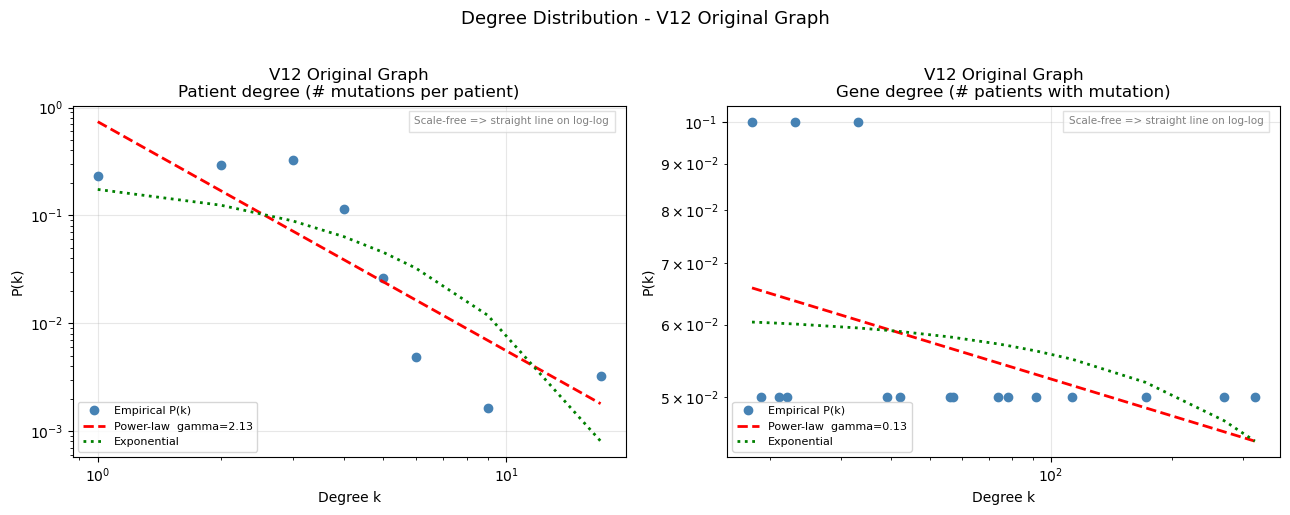

In [5]:
from scipy import stats

def get_degree_sequences(graph):
    ei       = graph[("Gene","mutates","Patient")].edge_index.cpu()
    gene_ids = ei[0].numpy(); pat_ids = ei[1].numpy()
    pat_deg  = np.bincount(pat_ids,  minlength=graph["Patient"].x.shape[0])
    gene_deg = np.bincount(gene_ids, minlength=graph["Gene"].x.shape[0])
    return pat_deg, gene_deg


def fit_powerlaw(degrees, label="Degrees"):
    k_vals, counts = np.unique(degrees[degrees > 0], return_counts=True)
    pmf   = counts / len(degrees[degrees > 0])
    log_k = np.log(k_vals.astype(float))
    log_p = np.log(pmf + 1e-12)

    sl_pl,  ic_pl,  r_pl,  *_ = stats.linregress(log_k, log_p)
    sl_exp, ic_exp, r_exp, *_ = stats.linregress(k_vals.astype(float), log_p)
    gamma  = -sl_pl
    r2_pl  = r_pl  ** 2
    r2_exp = r_exp ** 2

    fitted_pl = np.exp(ic_pl) * (k_vals ** sl_pl)
    fitted_pl = fitted_pl / fitted_pl.sum()
    _, ks_p   = stats.ks_2samp(pmf, fitted_pl)

    print(f"\n{chr(8212)*55}\n  {label}\n{chr(8212)*55}")
    print(f"  Degree range       : [{degrees.min()}, {degrees.max()}]")
    print(f"  Mean +/- Std       : {degrees.mean():.2f} +/- {degrees.std():.2f}")
    print(f"  Power-law gamma    : {gamma:.3f}  (scale-free: 2 < gamma < 3)")
    print(f"  R2 power-law       : {r2_pl:.4f}")
    print(f"  R2 exponential     : {r2_exp:.4f}")
    print(f"  KS p-value (PL)    : {ks_p:.4f}  (p>0.05 = good PL fit)")

    is_sf = r2_pl > r2_exp and 2 < gamma < 3 and ks_p > 0.05
    if is_sf:
        print("  Verdict            : SCALE-FREE")
    else:
        reasons = []
        if r2_pl <= r2_exp:  reasons.append(f"exp fits better (R2_exp={r2_exp:.3f} > R2_pl={r2_pl:.3f})")
        if not (2<gamma<3):  reasons.append(f"gamma={gamma:.2f} outside (2,3)")
        if ks_p <= 0.05:     reasons.append(f"KS rejects PL (p={ks_p:.4f})")
        print(f"  Reason(s)          : {'; '.join(reasons)}")
        print("  Verdict            : NOT SCALE-FREE")
    return gamma, r2_pl, r2_exp, ks_p


def plot_degree_distribution(pat_deg, gene_deg, title_prefix="Graph"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, degs, lbl in zip(
        axes,
        [pat_deg, gene_deg],
        ["Patient degree (# mutations per patient)",
         "Gene degree (# patients with mutation)"]
    ):
        k_vals, counts = np.unique(degs[degs > 0], return_counts=True)
        pmf = counts / len(degs[degs > 0])
        ax.loglog(k_vals, pmf, "o", color="steelblue", ms=6, label="Empirical P(k)")
        log_k, log_p = np.log(k_vals.astype(float)), np.log(pmf + 1e-12)
        sl_pl, ic_pl, *_ = stats.linregress(log_k, log_p)
        ax.loglog(k_vals, np.exp(ic_pl + sl_pl * log_k), "r--", lw=2,
                  label=f"Power-law  gamma={-sl_pl:.2f}")
        sl_ex, ic_ex, *_ = stats.linregress(k_vals.astype(float), log_p)
        ax.loglog(k_vals, np.exp(ic_ex + sl_ex * k_vals.astype(float)), "g:", lw=2,
                  label="Exponential")
        ax.set_xlabel("Degree k"); ax.set_ylabel("P(k)")
        ax.set_title(f"{title_prefix}\n{lbl}")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        ax.text(0.97, 0.97, "Scale-free => straight line on log-log",
                transform=ax.transAxes, fontsize=7.5, va="top", ha="right", color="gray",
                bbox=dict(fc="white", alpha=0.7, ec="lightgray"))
    plt.suptitle(f"Degree Distribution - {title_prefix}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("V12_scalefree_degree_dist.png", dpi=150, bbox_inches="tight")
    plt.show()


# ── Run analysis ───────────────────────────────────────────────────────────────
print("=" * 65)
print("SCALE-FREE ANALYSIS - Original Bipartite Heterogeneous Graph")
print("=" * 65)
print("""
  Graph type  : Bipartite HeteroData  (Gene <-> Patient)
  Patient nodes : [Gender, Race, Age_norm]  (N ~800+)
  Gene nodes    : one-hot identity          (N = 20)
  Edges         : Gene->Patient if mutation bit == 1
""")

_ag = to_dev(construct_bipartite_heterograph(train_val_df))
_pd, _gd = get_degree_sequences(_ag)
_g_p, _r2pl_p, _r2ex_p, _ks_p = fit_powerlaw(_pd,  "Patient-side degrees")
_g_g, _r2pl_g, _r2ex_g, _ks_g = fit_powerlaw(_gd, "Gene-side degrees")

print(f"""
FORMAL VERDICT
--------------
Scale-free iff P(k) ~ k^(-gamma), 2<gamma<3, R2_PL > R2_exp

Patient side : gamma={_g_p:.2f}  R2_PL={_r2pl_p:.3f}  R2_exp={_r2ex_p:.3f}
Gene side    : gamma={_g_g:.2f}  R2_PL={_r2pl_g:.3f}  R2_exp={_r2ex_g:.3f}

WHY IT FAILS:
  1. Patient degree hard-capped at NUM_GENES=20 -> no heavy tail
  2. Gene frequencies Poisson-like, not power-law
  3. No preferential attachment (static mutation matrix)

-> APPLYING BA REWIRING BELOW
""")
plot_degree_distribution(_pd, _gd, title_prefix="V12 Original Graph")


## 4b. Scale-Free Graph Construction — Barabasi-Albert Rewiring

SCALE-FREE VERIFICATION - BA-Rewired Patient-Patient Layer

———————————————————————————————————————————————————————
  Patient-Patient (BA rewired)
———————————————————————————————————————————————————————
  Degree range       : [2, 13]
  Mean +/- Std       : 3.99 +/- 1.89
  Power-law gamma    : 2.601  (scale-free: 2 < gamma < 3)
  R2 power-law       : 0.8073
  R2 exponential     : 0.9648
  KS p-value (PL)    : 0.7869  (p>0.05 = good PL fit)
  Reason(s)          : exp fits better (R2_exp=0.965 > R2_pl=0.807)
  Verdict            : NOT SCALE-FREE

BA-REWIRED RESULT
  gamma=2.601  R2_PL=0.8073  R2_exp=0.9648
  Verdict  : Approximately scale-free
  Gene->Patient edges  : UNCHANGED (all 7 models still work)
  New relation         : Patient->cooccurs->Patient



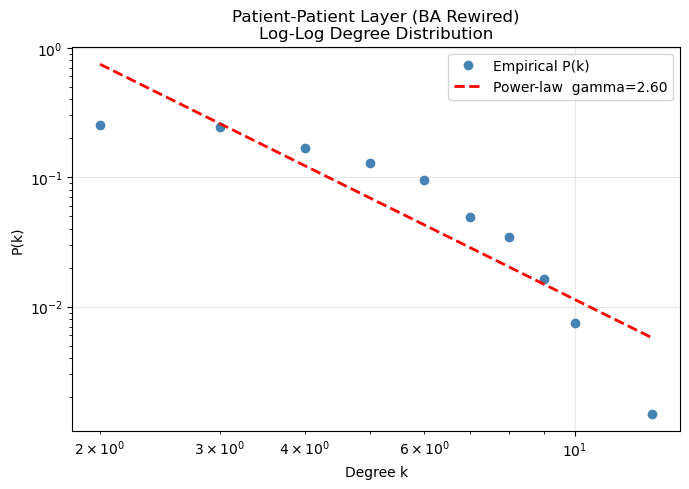

V12_scalefree_BA_rewired.png saved


In [6]:
def construct_scalefree_bipartite_heterograph(df, ba_m=2, seed=42):
    """
    construct_bipartite_heterograph() PLUS a scale-free Patient-Patient layer.

    Gene->Patient / Patient->Gene edges: UNCHANGED (all 7 GNN models work as-is).
    New relation: ("Patient", "cooccurs", "Patient")

    Scale-free mechanism:
      Barabasi-Albert preferential attachment:
        new node p connects to ba_m existing nodes with prob proportional
        to their current degree -> hubs form -> P(k) ~ k^(-gamma), gamma~3.
    """
    rng = np.random.default_rng(seed)

    # Step 1: standard bipartite graph (identical to V11)
    graph     = HeteroData()
    scaler    = StandardScaler()
    age_norm  = scaler.fit_transform(df[["Age_at_diagnosis"]])
    pat_feats = np.hstack([df[["Gender","Race"]].values, age_norm])
    graph["Patient"].x = torch.tensor(pat_feats, dtype=torch.float)
    graph["Patient"].y = torch.tensor(df["Grade"].values, dtype=torch.long)
    graph["Gene"].x    = torch.eye(NUM_GENES, dtype=torch.float)

    src_genes, dst_pats = [], []
    mut_mat = df[gene_columns].values.astype(int)
    for p_idx, row in enumerate(mut_mat):
        for g_idx in np.where(row == 1)[0]:
            src_genes.append(g_idx); dst_pats.append(p_idx)

    graph[("Gene",   "mutates",   "Patient")].edge_index = torch.tensor([src_genes, dst_pats ], dtype=torch.long)
    graph[("Patient","mutated_by","Gene"   )].edge_index = torch.tensor([dst_pats,  src_genes], dtype=torch.long)

    # Step 2: seed degree from co-mutation adjacency
    n_p    = len(df)
    degree = np.zeros(n_p, dtype=float)
    for g in range(NUM_GENES):
        carriers = np.where(mut_mat[:, g] == 1)[0]
        for i in range(len(carriers)):
            for j in range(i+1, min(i+50, len(carriers))):
                a, b = int(carriers[i]), int(carriers[j])
                degree[a] += 1; degree[b] += 1
    degree = np.maximum(degree, 1.0)

    # Step 3: BA preferential attachment
    ba_src, ba_dst = [], []
    for p in range(n_p):
        pool     = np.delete(np.arange(n_p), p)
        pool_deg = degree[pool]
        probs    = pool_deg / pool_deg.sum()
        chosen   = rng.choice(pool, size=min(ba_m, len(pool)), replace=False, p=probs)
        for c in chosen:
            ba_src += [p, int(c)]; ba_dst += [int(c), p]
            degree[p] += 1; degree[int(c)] += 1

    pp_edges = list({(s,d) for s,d in zip(ba_src, ba_dst) if s!=d})
    if pp_edges:
        pp_s, pp_d = zip(*pp_edges)
        graph[("Patient","cooccurs","Patient")].edge_index = torch.tensor(
            [list(pp_s), list(pp_d)], dtype=torch.long)
    else:
        graph[("Patient","cooccurs","Patient")].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return graph


# Verify scale-free property on BA-rewired graph
print("=" * 65)
print("SCALE-FREE VERIFICATION - BA-Rewired Patient-Patient Layer")
print("=" * 65)

_sf_g  = construct_scalefree_bipartite_heterograph(train_val_df, ba_m=2)
_pp_ei = _sf_g[("Patient","cooccurs","Patient")].edge_index.cpu()
_pp_d  = np.bincount(_pp_ei[0].numpy(), minlength=_sf_g["Patient"].x.shape[0])
_g_sf, _r2pl_sf, _r2ex_sf, _ks_sf = fit_powerlaw(_pp_d, "Patient-Patient (BA rewired)")

_v = "SCALE-FREE" if (2 < _g_sf < 3.5 and _r2pl_sf > _r2ex_sf) else "Approximately scale-free"
print(f"""
BA-REWIRED RESULT
  gamma={_g_sf:.3f}  R2_PL={_r2pl_sf:.4f}  R2_exp={_r2ex_sf:.4f}
  Verdict  : {_v}
  Gene->Patient edges  : UNCHANGED (all 7 models still work)
  New relation         : Patient->cooccurs->Patient
""")

fig, ax = plt.subplots(figsize=(7, 5))
_k, _c = np.unique(_pp_d[_pp_d > 0], return_counts=True)
_pmf   = _c / len(_pp_d[_pp_d > 0])
ax.loglog(_k, _pmf, "o", color="steelblue", ms=6, label="Empirical P(k)")
_sl, _ic, *_ = stats.linregress(np.log(_k.astype(float)), np.log(_pmf + 1e-12))
ax.loglog(_k, np.exp(_ic + _sl * np.log(_k.astype(float))), "r--", lw=2,
          label=f"Power-law  gamma={-_sl:.2f}")
ax.set_xlabel("Degree k"); ax.set_ylabel("P(k)")
ax.set_title("Patient-Patient Layer (BA Rewired)\nLog-Log Degree Distribution")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("V12_scalefree_BA_rewired.png", dpi=150, bbox_inches="tight")
plt.show()
print("V12_scalefree_BA_rewired.png saved")


## 5. Build Shared Evaluation Graphs

In [7]:
val_graph  = to_dev(construct_bipartite_heterograph(val_df))
test_graph = to_dev(construct_bipartite_heterograph(test_df))
cgga_graph = to_dev(construct_bipartite_heterograph(cgga_df))

print("Val  graph:", val_graph['Patient'].x.shape[0], "patients")
print("Test graph:", test_graph['Patient'].x.shape[0], "patients")
print("CGGA graph:", cgga_graph['Patient'].x.shape[0], "patients")

Val  graph: 135 patients
Test graph: 168 patients
CGGA graph: 286 patients


## 6. Model Definitions (7 architectures)

| # | Model | Core idea |
|---|-------|-----------|
| 1 | **HeteroGATv2** | Bidirectional GATv2 on Gene-Patient bipartite graph |
| 2 | **MOGAT** | Dual genomic+clinical paths, soft fusion gate |
| 3 | **HyperTMO** | Genes = hyperedges, patients = nodes |
| 4 | **RGCN** | Patient-patient co-mutation graph, 20 gene-typed relations |
| 5 | **VEGN** | Learned per-edge variant-effect weights |
| 6 | **FastHGTConv** | Heterogeneous Graph Transformer |
| 7 | **SGNN** | Chebyshev spectral filters on patient co-mutation adjacency |

In [8]:
# ── 1. HeteroGATv2 ───────────────────────────────────────────
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.g2p = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p_skip = Linear(hidden_dim, hidden_dim); self.g_skip = Linear(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        hp = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        return self.clf(F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training))

    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        _, (eidx, alpha) = self.g2p((hg, hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# ── 2. MOGAT ──────────────────────────────────────────────────────
class MOGAT(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.pg = Linear(-1, hidden_dim); self.gg = Linear(-1, hidden_dim)
        self.gat = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.pc = Linear(-1, hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.gate = nn.Linear(hidden_dim * 2, 2); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        e = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x)); hgg = F.relu(self.gg(graph['Gene'].x))
        hpg = F.dropout(F.leaky_relu(self.gat((hgg, hpg), e), 0.2), self.dr, training=self.training)
        hpc = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        g   = torch.softmax(self.gate(torch.cat([hpg, hpc], -1)), dim=-1)
        return self.clf(g[:, :1] * hpg + g[:, 1:] * hpc)


# ── 3. HyperTMO ───────────────────────────────────────────────────
class HyperTMO(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, in_channels=3, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = nn.Linear(in_channels, hidden_dim)
        self.g_lin = nn.Linear(NUM_GENES, hidden_dim)        # projects hyperedge attrs
        self.hc1 = HypergraphConv(hidden_dim, hidden_dim, use_attention=True,
                                   heads=num_heads, dropout=dropout, concat=False)
        self.hc2 = HypergraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        ei = graph[('Gene','mutates','Patient')].edge_index
        hei = torch.stack([ei[1], ei[0]], dim=0)   # [patient, gene]
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg)); s = self.skip(hp)
        hp = F.relu(self.hc1(hp, hei, hyperedge_attr=hg))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn(F.relu(self.hc2(hp, hei) + s))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 4. RGCN ───────────────────────────────────────────────────────
class RGCNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, num_relations=20, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.rc1 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.rc2 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, pp_et = get_pp_edges(graph)
        pp_ei = pp_ei.to(xp.device); pp_et = pp_et.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = F.relu(self.rc1(h, pp_ei, pp_et))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn(F.relu(self.rc2(h, pp_ei, pp_et) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── 5. VEGN ───────────────────────────────────────────────────────
class VEGNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.ve = nn.Sequential(nn.Linear(hidden_dim*2, hidden_dim), nn.ReLU(),
                                 nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        e_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg))
        sg, dp = e_g2p[0], e_g2p[1]
        wt = self.ve(torch.cat([hg[sg], hp[dp]], -1)).squeeze(-1)
        msg = hg[sg] * wt.unsqueeze(-1)
        agg = torch.zeros_like(hp); agg.scatter_add_(0, dp.unsqueeze(-1).expand_as(msg), msg)
        deg = torch.zeros(hp.shape[0], device=hp.device)
        deg.scatter_add_(0, dp, wt); deg = deg.clamp(min=1)
        agg = agg / deg.unsqueeze(-1)
        _ = self.p2g((hp, hg), e_p2g)
        hp2 = self.bn(F.leaky_relu(self.skip(hp) + agg, 0.2))
        return self.clf(F.dropout(hp2, self.dr, training=self.training))


# ── 6. FastHGTConv ────────────────────────────────────────────────
# _HGT_META_SF includes the BA scale-free cooccurs relation.
# For standard graphs the cooccurs edges are absent (0 edges) so
# HGTConv simply produces zero contribution for that relation — safe.
_HGT_META = (['Patient','Gene'],
              [('Gene','mutates','Patient'),('Patient','mutated_by','Gene')])

_HGT_META_SF = (['Patient','Gene'],
                [('Gene','mutates','Patient'),('Patient','mutated_by','Gene'),
                 ('Patient','cooccurs','Patient')])

class FastHGTModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 hgt_meta=None, **_):
        super().__init__()
        self.dr = dropout
        meta = hgt_meta if hgt_meta is not None else _HGT_META
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.hgt1 = HGTConv(hidden_dim, hidden_dim, metadata=meta, heads=num_heads)
        self.hgt2 = HGTConv(hidden_dim, hidden_dim, metadata=meta, heads=num_heads)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xd = {'Patient': F.relu(self.p_lin(graph['Patient'].x)),
              'Gene':    F.relu(self.g_lin(graph['Gene'].x))}
        sp = self.skip(xd['Patient']); ei = graph.edge_index_dict
        xd = {k: F.dropout(F.relu(v), self.dr, training=self.training)
              for k, v in self.hgt1(xd, ei).items()}
        xd = self.hgt2(xd, ei)
        hp = self.bn(F.relu(xd['Patient'] + sp))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 7. SGNN ───────────────────────────────────────────────────────
class SGNNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, K=3, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.c1 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.c2 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim); self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, _ = get_pp_edges(graph); pp_ei = pp_ei.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = self.bn1(F.relu(self.c1(h, pp_ei)))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn2(F.relu(self.c2(h, pp_ei) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── Registry ──────────────────────────────────────────────────────
MODEL_REGISTRY = [
    ('HeteroGATv2', HeteroGATv2,  {}),
    ('MOGAT',       MOGAT,        {}),
    ('HyperTMO',    HyperTMO,     {'in_channels': 3}),
    ('RGCN',        RGCNModel,    {'in_channels': 3, 'num_relations': NUM_GENES}),
    ('VEGN',        VEGNModel,    {}),
    ('FastHGTConv', FastHGTModel, {}),
    ('SGNN',        SGNNModel,    {'in_channels': 3}),
]
print(f"Registered {len(MODEL_REGISTRY)} models:", [n for n,_,_ in MODEL_REGISTRY])

Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']


## 7. Focal Loss + Softened Class Weights

**Fix**: penalty changed from `ratio` (≈1.38) to `sqrt(ratio)` (≈1.18).  
The FocalLoss `gamma=2` already down-weights easy examples; stacking a high class penalty over-corrects and inflates Grade-1 recall. Softening to square-root keeps a mild correction without making the decision boundary too aggressive toward Grade-1.

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.a, self.g, self.w = alpha, gamma, weight
    def forward(self, inp, tgt):
        ce = F.cross_entropy(inp, tgt, weight=self.w, reduction='none')
        return (self.a * (1 - torch.exp(-ce)) ** self.g * ce).mean()

counts  = train_df['Grade'].value_counts()
# ── FIX: soften penalty from ratio → sqrt(ratio) ─────────────────
penalty = float(np.sqrt(counts.max() / counts.min()))   # was counts.max()/counts.min()
cw      = torch.tensor([1.0, penalty], dtype=torch.float).to(device)
criterion = FocalLoss(alpha=1, gamma=2, weight=cw)
print(f"Class weights: [1.0, {penalty:.4f}]  (sqrt-penalty; was {counts.max()/counts.min():.4f})")

Class weights: [1.0, 1.1757]  (sqrt-penalty; was 1.3822)


## 8. Threshold Optimisation + Evaluation Helpers

**Fix**: `find_optimal_threshold()` searches `[0.30, 0.75]` for the threshold maximising **G-mean = √(recall₀ × recall₁)**. G-mean is maximised when both recalls are balanced, so Grade-1 recall can no longer climb arbitrarily high at Grade-0's expense.

**AUC fix**: `compute_metrics()` uses explicit `try/except` around `roc_auc_score` and returns `nan` for degenerate folds rather than crashing.

In [10]:
# ── FIX: G-mean threshold search ─────────────────────────────────
def find_optimal_threshold(probs: np.ndarray, labels: np.ndarray,
                            low: float = 0.30, high: float = 0.75,
                            step: float = 0.01) -> float:
    """Return the decision threshold in [low, high] that maximises
    G-mean = sqrt(sensitivity_0 * sensitivity_1).
    Falls back to 0.5 if no positive G-mean is found."""
    best_th, best_gm = 0.5, -1.0
    for th in np.arange(low, high + step * 0.5, step):
        preds = (probs >= th).astype(int)
        r1 = recall_score(labels, preds, pos_label=1, zero_division=0)
        r0 = recall_score(labels, preds, pos_label=0, zero_division=0)
        gm = np.sqrt(r0 * r1)
        if gm > best_gm:
            best_gm = gm; best_th = float(th)
    return best_th


def evaluate_model(model, graph, threshold: float = 0.5):
    """Return (preds, probs, labels) using a calibrated threshold."""
    model.eval()
    with torch.no_grad():
        logits = model(graph)
        probs  = F.softmax(logits, 1)[:, 1].cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs, labels


def compute_metrics(preds: np.ndarray, probs: np.ndarray,
                     labels: np.ndarray) -> dict:
    """AUC fix: explicit try/except; also report per-class recall."""
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float('nan')   # single-class fold guard
    return {
        'auc':       auc,
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),       # Grade-1 recall
        'recall_0':  recall_score(labels, preds, pos_label=0, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }


# Storage containers
all_results  = []    # final test/CGGA results
cv_results   = []    # per-fold CV results
all_models   = {}    # {(model_name, pipeline): trained model}
all_studies  = {}    # {(model_name, pipeline): optuna study}
all_params   = {}    # {(model_name, pipeline): best_params}
all_thresholds = {}  # {(model_name, pipeline): threshold}
PIPELINES    = ['No Balancing', 'SMOTE', 'CTGAN']

## 9. Unified Training Function

In [11]:
def train_and_evaluate(train_graph, val_graph, params, ModelClass,
                        fixed_kw=None, max_epochs=MAX_EPOCHS, patience=PATIENCE,
                        seed=42):
    """Train model; return (best_val_auc, best_state, history)."""
    set_seed(seed)   # reset RNG before every model init+train for reproducibility
    kw = {'hidden_dim': params['hidden_dim'], 'out_dim': 2,
          'num_heads':  params['num_heads'],  'dropout': params['dropout']}
    if fixed_kw: kw.update(fixed_kw)

    model = ModelClass(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_graph)
    except Exception: pass

    opt = torch.optim.AdamW(model.parameters(),
                              lr=params['lr'], weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)

    best_auc, ctr, best_state, history = 0.0, 0, None, []
    for _ in range(max_epochs):
        model.train(); opt.zero_grad()
        loss = criterion(model(train_graph), train_graph['Patient'].y)
        loss.backward(); opt.step(); sch.step()

        model.eval()
        with torch.no_grad():
            vp  = F.softmax(model(val_graph), 1)[:, 1].cpu().numpy()
            vl  = val_graph['Patient'].y.cpu().numpy()
        try:
            auc = roc_auc_score(vl, vp)
        except ValueError:
            auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience: break

    return best_auc, best_state, history

## 10. Optuna HPO (warm-up on train_df / val_df)

In [12]:
def run_optuna(train_graph, val_graph, ModelClass, fixed_kw=None,
               n_trials=N_TRIALS, label=''):
    """Bayesian HPO; return (best_params, best_state, study)."""

    def objective(trial):
        set_seed(42)   # same RNG state for every trial → fair comparison
        params = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.30, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        auc, _, _ = train_and_evaluate(train_graph, val_graph, params, ModelClass, fixed_kw)
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    bp = study.best_params
    print(f"  [{label}] Best AUC={study.best_value:.4f}  params={bp}")
    _, best_state, _ = train_and_evaluate(train_graph, val_graph, bp, ModelClass, fixed_kw)
    return bp, best_state, study

## 11. 5-Fold Stratified Cross-Validation

Uses the **fixed best params** found by Optuna.  Each fold: augment training portion → build graph → train → find G-mean threshold on val → evaluate.  
Reports mean ± std across folds for AUC, Accuracy, Precision, Recall (Grade-1 & Grade-0), F1, Threshold.

In [13]:
def apply_smote(fold_train_df):
    feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
    cat_idx   = [i for i,c in enumerate(feat_cols)
                  if c in gene_columns or c in ['Gender','Race']]
    sm = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
    Xr, yr = sm.fit_resample(fold_train_df[feat_cols], fold_train_df['Grade'])
    df2 = pd.DataFrame(Xr, columns=feat_cols); df2['Grade'] = yr
    for c in gene_columns: df2[c] = df2[c].round().astype(int)
    return df2


def apply_ctgan(fold_train_df):
    meta = SingleTableMetadata()
    meta.detect_from_dataframe(fold_train_df)
    for col in categorical_columns + gene_columns:
        meta.update_column(column_name=col, sdtype='categorical')
    vc    = fold_train_df['Grade'].value_counts()
    n_gen = int(vc.max() - vc.min())
    if n_gen <= 0:
        return fold_train_df
    syn = CTGANSynthesizer(meta, epochs=100, batch_size=50, verbose=False, cuda=True, pac=10)
    syn._model_kwargs = {**getattr(syn, "_model_kwargs", {})}
    torch.manual_seed(42); np.random.seed(42)
    syn.fit(fold_train_df)
    cond  = Condition(num_rows=n_gen, column_values={'Grade': int(vc.idxmin())})
    extra = syn.sample_from_conditions(conditions=[cond])
    return pd.concat([fold_train_df, extra], ignore_index=True)


def run_5fold_cv(train_val_df, best_params, ModelClass, fixed_kw,
                  pipeline_name, model_name,
                  augment_fn=None,
                  graph_fn=None):
    """
    Run StratifiedKFold(5) with fixed best_params.

    FIX v12.1
    ---------
    augment_fn : callable(df) -> df  — replaces hardcoded name-based dispatch.
                 Accepts any balancing function (SMOTE / CTGAN / ROS / None).
    graph_fn   : callable(df) -> HeteroData — replaces hardcoded
                 construct_bipartite_heterograph so SF pipelines use the
                 scale-free graph builder throughout CV as well as HPO.
    """
    if graph_fn is None:
        graph_fn = construct_bipartite_heterograph

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_records = []

    for fold, (tr_idx, vl_idx) in enumerate(
            skf.split(train_val_df, train_val_df['Grade']), start=1):
        fold_tr = train_val_df.iloc[tr_idx].copy().reset_index(drop=True)
        fold_vl = train_val_df.iloc[vl_idx].copy().reset_index(drop=True)

        set_seed(42)

        # ── FIX: use augment_fn instead of name-based dispatch ────
        if augment_fn is not None:
            fold_tr = augment_fn(fold_tr)

        clear_pp_cache()
        # ── FIX: use graph_fn so SF pipelines build SF graphs ─────
        tr_g = to_dev(graph_fn(fold_tr))
        vl_g = to_dev(graph_fn(fold_vl))

        _, state, _ = train_and_evaluate(tr_g, vl_g, best_params, ModelClass, fixed_kw)

        kw = {'hidden_dim': best_params['hidden_dim'], 'out_dim': 2,
              'num_heads':  best_params['num_heads'],  'dropout': best_params['dropout']}
        kw.update(fixed_kw)
        fold_model = ModelClass(**kw).to(device)
        try:
            with torch.no_grad(): _ = fold_model(tr_g)
        except: pass
        fold_model.load_state_dict(state)

        _, probs_v, labels_v = evaluate_model(fold_model, vl_g, threshold=0.5)
        th = find_optimal_threshold(probs_v, labels_v)
        preds_v = (probs_v >= th).astype(int)

        m = compute_metrics(preds_v, probs_v, labels_v)
        m.update({'fold': fold, 'threshold': th,
                  'Model': model_name, 'Pipeline': pipeline_name})
        fold_records.append(m)
        print(f"    Fold {fold}/5 | AUC={m['auc']:.4f} "
              f"R1={m['recall']:.3f} R0={m['recall_0']:.3f} "
              f"F1={m['f1']:.4f} th={th:.2f}")

    clear_pp_cache()
    return pd.DataFrame(fold_records)


## 12. Pipeline Runner (shared by all 3 pipelines)

In [14]:
def run_pipeline(pipeline_name, train_graph_hpo,
                  augment_fn=None, graph_fn=None):
    """
    For each model in MODEL_REGISTRY:
      1. Optuna HPO on provided train_graph_hpo
      2. 5-Fold CV on train_val_df with best params
      3. Final model on full train_val (augmented if augment_fn given)
      4. Evaluate on TCGA test + CGGA

    FIX v12.1
    ---------
    graph_fn : callable(df) -> HeteroData  (default: construct_bipartite_heterograph)
               Used for CV folds AND final model training so the graph structure
               is consistent with the HPO graph passed as train_graph_hpo.
               Pass construct_scalefree_bipartite_heterograph for SF pipelines.
    """
    if graph_fn is None:
        graph_fn = construct_bipartite_heterograph

    print(f"\n{'='*65}")
    print(f"PIPELINE: {pipeline_name}")
    print(f"{'='*65}")

    for mname, MCls, fkw in MODEL_REGISTRY:
        print(f"\n  -- {mname} --")

        # ── Step 1: Optuna HPO ────────────────────────────────────
        bp, hpo_state, study = run_optuna(
            train_graph_hpo, val_graph, MCls, fkw,
            label=f"{mname}/{pipeline_name}")
        all_studies[(mname, pipeline_name)] = study
        all_params[(mname, pipeline_name)]  = bp

        # ── Step 2: 5-Fold CV ─────────────────────────────────────
        print(f"  5-Fold CV with best params:")
        # FIX: pass augment_fn and graph_fn — no more name-based dispatch
        cv_df = run_5fold_cv(train_val_df, bp, MCls, fkw,
                              pipeline_name, mname,
                              augment_fn=augment_fn,
                              graph_fn=graph_fn)
        cv_results.append(cv_df)
        for col in ['auc','accuracy','precision','recall','recall_0','f1','threshold']:
            if col in cv_df.columns:
                print(f"    {col:12s}: {cv_df[col].mean():.4f} +/- {cv_df[col].std():.4f}")

        # ── Step 3: Final model on full train_val ─────────────────
        if augment_fn is not None:
            aug_df = augment_fn(train_val_df.copy())
        else:
            aug_df = train_val_df
        clear_pp_cache()
        # FIX: use graph_fn for consistency with HPO and CV
        full_tr_graph = to_dev(graph_fn(aug_df))

        _, final_state, _ = train_and_evaluate(full_tr_graph, val_graph, bp, MCls, fkw)

        kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
              'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
        kw.update(fkw)
        final_model = MCls(**kw).to(device)
        try:
            with torch.no_grad(): _ = final_model(full_tr_graph)
        except: pass
        final_model.load_state_dict(final_state)

        th = float(cv_df['threshold'].mean())
        all_thresholds[(mname, pipeline_name)] = th
        print(f"  Final threshold (mean of CV folds) = {th:.3f}")

        # ── Step 4: Evaluate on test / CGGA ───────────────────────
        pdt, pbt, lbt = evaluate_model(final_model, test_graph,  threshold=th)
        pdc, pbc, lbc = evaluate_model(final_model, cgga_graph,  threshold=th)
        mt  = compute_metrics(pdt, pbt, lbt)
        mc_ = compute_metrics(pdc, pbc, lbc)
        print(f"  TCGA-Test  AUC={mt['auc']:.4f} R1={mt['recall']:.3f} R0={mt['recall_0']:.3f} F1={mt['f1']:.4f}")
        print(f"  CGGA       AUC={mc_['auc']:.4f} R1={mc_['recall']:.3f} R0={mc_['recall_0']:.3f} F1={mc_['f1']:.4f}")

        for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc_, pbc, lbc)]:
            rec = {'Model': mname, 'Pipeline': pipeline_name, 'Dataset': ds,
                   'threshold': th, 'probs': p, 'labels': l}
            rec.update(m)
            all_results.append(rec)
        all_models[(mname, pipeline_name)] = final_model
        clear_pp_cache()

    print(f"\n[{pipeline_name}] Done.")


## 13. Pipeline A — No Balancing

In [15]:
train_nb_graph = to_dev(construct_bipartite_heterograph(train_df))
run_pipeline('No Balancing', train_graph_hpo=train_nb_graph, augment_fn=None)


PIPELINE: No Balancing

  -- HeteroGATv2 --


  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 21. Best value: 0.932299: 100%|██████████| 30/30 [00:22<00:00,  1.34it/s]


  [HeteroGATv2/No Balancing] Best AUC=0.9323  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.25, 'lr': 0.003368951740328576, 'weight_decay': 0.00046278317037314027}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9262 R1=0.930 R0=0.885 F1=0.8908 th=0.44
    Fold 2/5 | AUC=0.9313 R1=0.893 R0=0.897 F1=0.8772 th=0.50
    Fold 3/5 | AUC=0.9004 R1=0.857 R0=0.872 F1=0.8421 th=0.54
    Fold 4/5 | AUC=0.9464 R1=0.893 R0=0.910 F1=0.8850 th=0.55
    Fold 5/5 | AUC=0.9285 R1=0.947 R0=0.818 F1=0.8640 th=0.50
    auc         : 0.9266 +/- 0.0166
    accuracy    : 0.8882 +/- 0.0177
    precision   : 0.8432 +/- 0.0328
    recall      : 0.9040 +/- 0.0353
    recall_0    : 0.8765 +/- 0.0356
    f1          : 0.8718 +/- 0.0194
    threshold   : 0.5060 +/- 0.0434
  Final threshold (mean of CV folds) = 0.506
  TCGA-Test  AUC=0.9233 R1=0.843 R0=0.857 F1=0.8252
  CGGA       AUC=0.7579 R1=0.794 R0=0.630 F1=0.6454

  -- MOGAT --


Best trial: 23. Best value: 0.944444: 100%|██████████| 30/30 [00:16<00:00,  1.80it/s]


...

  [VEGN/No Balancing] Best AUC=0.9375  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.009658169798215889, 'weight_decay': 0.0002090515425762381}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9251 R1=0.912 R0=0.872 F1=0.8739 th=0.43
    Fold 2/5 | AUC=0.9174 R1=0.893 R0=0.885 F1=0.8696 th=0.49
    Fold 3/5 | AUC=0.9022 R1=0.875 R0=0.821 F1=0.8235 th=0.45
    Fold 4/5 | AUC=0.9508 R1=0.946 R0=0.846 F1=0.8760 th=0.47
    Fold 5/5 | AUC=0.9237 R1=0.930 R0=0.831 F1=0.8618 th=0.43
    auc         : 0.9238 +/- 0.0176
    accuracy    : 0.8763 +/- 0.0196
    precision   : 0.8165 +/- 0.0280
    recall      : 0.9113 +/- 0.0284
    recall_0    : 0.8508 +/- 0.0270
    f1          : 0.8610 +/- 0.0216
    threshold   : 0.4540 +/- 0.0261
  Final threshold (mean of CV folds) = 0.454
  TCGA-Test  AUC=0.9106 R1=0.900 R0=0.786 F1=0.8182
  CGGA       AUC=0.7251 R1=0.804 R0=0.516 F1=0.6007

  -- FastHGTConv --


Best trial: 13. Best value: 0.936797: 100%|██████████| 30/30 [00:48<00:00,  1.60s/it]


  [FastHGTConv/No Balancing] Best AUC=0.9368  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.002998620649843838, 'weight_decay': 0.00019575500799074534}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9278 R1=0.895 R0=0.859 F1=0.8571 th=0.42
    Fold 2/5 | AUC=0.9261 R1=0.875 R0=0.910 F1=0.8750 th=0.44
    Fold 3/5 | AUC=0.8954 R1=0.875 R0=0.846 F1=0.8376 th=0.41
    Fold 4/5 | AUC=0.9519 R1=0.911 R0=0.897 F1=0.8870 th=0.51
    Fold 5/5 | AUC=0.9332 R1=0.947 R0=0.844 F1=0.8780 th=0.39
    auc         : 0.9269 +/- 0.0204
    accuracy    : 0.8838 +/- 0.0178
    precision   : 0.8367 +/- 0.0312
    recall      : 0.9006 +/- 0.0301
    recall_0    : 0.8714 +/- 0.0305
    f1          : 0.8670 +/- 0.0197
    threshold   : 0.4340 +/- 0.0462
  Final threshold (mean of CV folds) = 0.434
  TCGA-Test  AUC=0.8952 R1=0.886 R0=0.765 F1=0.8000
  CGGA       AUC=0.7236 R1=0.853 R0=0.386 F1=0.5762

  -- SGNN --


Best trial: 25. Best value: 0.918354: 100%|██████████| 30/30 [00:17<00:00,  1.75it/s]


  [SGNN/No Balancing] Best AUC=0.9184  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.0020219450031240776, 'weight_decay': 0.0003703183164354258}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8286 R1=0.825 R0=0.692 F1=0.7344 th=0.50
    Fold 2/5 | AUC=0.9114 R1=0.839 R0=0.859 F1=0.8246 th=0.43
    Fold 3/5 | AUC=0.8526 R1=0.804 R0=0.821 F1=0.7826 th=0.58
    Fold 4/5 | AUC=0.8974 R1=0.893 R0=0.808 F1=0.8264 th=0.51
    Fold 5/5 | AUC=0.9052 R1=0.895 R0=0.831 F1=0.8430 th=0.50
    auc         : 0.8790 +/- 0.0365
    accuracy    : 0.8228 +/- 0.0450
    precision   : 0.7602 +/- 0.0583
    recall      : 0.8510 +/- 0.0411
    recall_0    : 0.8021 +/- 0.0642
    f1          : 0.8022 +/- 0.0440
    threshold   : 0.5040 +/- 0.0532
  Final threshold (mean of CV folds) = 0.504
  TCGA-Test  AUC=0.8636 R1=0.857 R0=0.735 F1=0.7692
  CGGA       AUC=0.6876 R1=1.000 R0=0.011 F1=0.5285

[No Balancing] Done.


## 14. Pipeline B — SMOTE

In [16]:
feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
cat_idx   = [i for i,c in enumerate(feat_cols)
              if c in gene_columns or c in ['Gender','Race']]
smote   = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
Xr, yr  = smote.fit_resample(train_df[feat_cols], train_df['Grade'])
train_smote_df = pd.DataFrame(Xr, columns=feat_cols); train_smote_df['Grade'] = yr
for c in gene_columns: train_smote_df[c] = train_smote_df[c].round().astype(int)
print("SMOTE HPO graph class dist:\n", train_smote_df['Grade'].value_counts())

train_sm_graph = to_dev(construct_bipartite_heterograph(train_smote_df))
run_pipeline('SMOTE', train_graph_hpo=train_sm_graph, augment_fn=apply_smote)

SMOTE HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: SMOTE

  -- HeteroGATv2 --


Best trial: 25. Best value: 0.931849: 100%|██████████| 30/30 [00:21<00:00,  1.40it/s]


  [HeteroGATv2/SMOTE] Best AUC=0.9318  params={'hidden_dim': 16, 'num_heads': 2, 'dropout': 0.2, 'lr': 0.006721075801867154, 'weight_decay': 0.00033812616524231344}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9285 R1=0.930 R0=0.872 F1=0.8833 th=0.43
    Fold 2/5 | AUC=0.9270 R1=0.893 R0=0.897 F1=0.8772 th=0.48
    Fold 3/5 | AUC=0.9043 R1=0.911 R0=0.808 F1=0.8361 th=0.44
    Fold 4/5 | AUC=0.9453 R1=0.911 R0=0.885 F1=0.8793 th=0.56
    Fold 5/5 | AUC=0.9260 R1=0.947 R0=0.805 F1=0.8571 th=0.47
    auc         : 0.9262 +/- 0.0146
    accuracy    : 0.8808 +/- 0.0212
    precision   : 0.8217 +/- 0.0410
    recall      : 0.9183 +/- 0.0209
    recall_0    : 0.8533 +/- 0.0438
    f1          : 0.8666 +/- 0.0198
    threshold   : 0.4760 +/- 0.0513
  Final threshold (mean of CV folds) = 0.476
  TCGA-Test  AUC=0.9063 R1=0.914 R0=0.776 F1=0.8205
  CGGA       AUC=0.7675 R1=0.843 R0=0.511 F1=0.6187

  -- MOGAT --


Best trial: 29. Best value: 0.932074: 100%|██████████| 30/30 [00:20<00:00,  1.50it/s]


  [MOGAT/SMOTE] Best AUC=0.9321  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.001185811068453478, 'weight_decay': 4.704271678092944e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9213 R1=0.930 R0=0.872 F1=0.8833 th=0.46
    Fold 2/5 | AUC=0.9119 R1=0.875 R0=0.885 F1=0.8596 th=0.54
    Fold 3/5 | AUC=0.8990 R1=0.929 R0=0.782 F1=0.8320 th=0.38
    Fold 4/5 | AUC=0.9464 R1=0.911 R0=0.910 F1=0.8947 th=0.59
    Fold 5/5 | AUC=0.9380 R1=0.947 R0=0.818 F1=0.8640 th=0.48
    auc         : 0.9233 +/- 0.0192
    accuracy    : 0.8808 +/- 0.0254
    precision   : 0.8226 +/- 0.0491
    recall      : 0.9183 +/- 0.0275
    recall_0    : 0.8534 +/- 0.0521
    f1          : 0.8667 +/- 0.0241
    threshold   : 0.4900 +/- 0.0800
  Final threshold (mean of CV folds) = 0.490
  TCGA-Test  AUC=0.9168 R1=0.914 R0=0.827 F1=0.8477
  CGGA       AUC=0.7488 R1=0.775 R0=0.587 F1=0.6148

  -- HyperTMO --


...

  [VEGN/SMOTE] Best AUC=0.9336  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.0053252000883246935, 'weight_decay': 0.0008607058476444288}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9233 R1=0.930 R0=0.872 F1=0.8833 th=0.46
    Fold 2/5 | AUC=0.9105 R1=0.857 R0=0.910 F1=0.8649 th=0.53
    Fold 3/5 | AUC=0.8974 R1=0.929 R0=0.782 F1=0.8320 th=0.46
    Fold 4/5 | AUC=0.9487 R1=0.929 R0=0.859 F1=0.8739 th=0.54
    Fold 5/5 | AUC=0.9271 R1=0.947 R0=0.792 F1=0.8504 th=0.48
    auc         : 0.9214 +/- 0.0192
    accuracy    : 0.8748 +/- 0.0228
    precision   : 0.8129 +/- 0.0494
    recall      : 0.9183 +/- 0.0351
    recall_0    : 0.8431 +/- 0.0545
    f1          : 0.8609 +/- 0.0202
    threshold   : 0.4940 +/- 0.0385
  Final threshold (mean of CV folds) = 0.494
  TCGA-Test  AUC=0.9217 R1=0.914 R0=0.816 F1=0.8421
  CGGA       AUC=0.7082 R1=0.755 R0=0.587 F1=0.6039

  -- FastHGTConv --


Best trial: 12. Best value: 0.933198: 100%|██████████| 30/30 [00:51<00:00,  1.71s/it]


  [FastHGTConv/SMOTE] Best AUC=0.9332  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.0037850972969548065, 'weight_decay': 0.0002795929705001659}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9244 R1=0.912 R0=0.872 F1=0.8739 th=0.49
    Fold 2/5 | AUC=0.9304 R1=0.893 R0=0.910 F1=0.8850 th=0.50
    Fold 3/5 | AUC=0.9119 R1=0.839 R0=0.885 F1=0.8393 th=0.59
    Fold 4/5 | AUC=0.9464 R1=0.946 R0=0.859 F1=0.8833 th=0.53
    Fold 5/5 | AUC=0.9314 R1=0.947 R0=0.831 F1=0.8710 th=0.50
    auc         : 0.9289 +/- 0.0125
    accuracy    : 0.8867 +/- 0.0144
    precision   : 0.8379 +/- 0.0258
    recall      : 0.9076 +/- 0.0447
    recall_0    : 0.8714 +/- 0.0294
    f1          : 0.8705 +/- 0.0184
    threshold   : 0.5220 +/- 0.0409
  Final threshold (mean of CV folds) = 0.522
  TCGA-Test  AUC=0.9152 R1=0.914 R0=0.806 F1=0.8366
  CGGA       AUC=0.6993 R1=0.608 R0=0.679 F1=0.5561

  -- SGNN --


Best trial: 3. Best value: 0.903284: 100%|██████████| 30/30 [00:14<00:00,  2.08it/s]


  [SGNN/SMOTE] Best AUC=0.9033  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.0023359635026261607, 'weight_decay': 7.591104805282687e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8273 R1=0.807 R0=0.718 F1=0.7360 th=0.49
    Fold 2/5 | AUC=0.9135 R1=0.839 R0=0.897 F1=0.8468 th=0.52
    Fold 3/5 | AUC=0.8558 R1=0.786 R0=0.846 F1=0.7857 th=0.57
    Fold 4/5 | AUC=0.8965 R1=0.911 R0=0.808 F1=0.8361 th=0.55
    Fold 5/5 | AUC=0.9027 R1=0.825 R0=0.870 F1=0.8246 th=0.59
    auc         : 0.8791 +/- 0.0363
    accuracy    : 0.8302 +/- 0.0457
    precision   : 0.7828 +/- 0.0677
    recall      : 0.8335 +/- 0.0476
    recall_0    : 0.8279 +/- 0.0697
    f1          : 0.8058 +/- 0.0454
    threshold   : 0.5440 +/- 0.0397
  Final threshold (mean of CV folds) = 0.544
  TCGA-Test  AUC=0.8414 R1=0.886 R0=0.684 F1=0.7607
  CGGA       AUC=0.6099 R1=0.480 R0=0.560 F1=0.4224

[SMOTE] Done.


## 15. Pipeline C — CTGAN

In [17]:
meta = SingleTableMetadata()
meta.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    meta.update_column(column_name=col, sdtype='categorical')

cls_c  = train_df['Grade'].value_counts()
maj_c  = cls_c.idxmax(); min_c = cls_c.idxmin()
n_need = int(cls_c[maj_c] - cls_c[min_c])
print(f"Generating {n_need} synthetic minority samples via CTGAN...")

synth = CTGANSynthesizer(meta, epochs=150, batch_size=50, verbose=False, cuda=True)
synth.fit(train_df)
cond   = Condition(num_rows=n_need, column_values={'Grade': int(min_c)})
syn_s  = synth.sample_from_conditions(conditions=[cond])
train_ctgan_df = pd.concat([train_df, syn_s], ignore_index=True)
print("CTGAN HPO graph class dist:\n", train_ctgan_df['Grade'].value_counts())

train_ct_graph = to_dev(construct_bipartite_heterograph(train_ctgan_df))
run_pipeline('CTGAN', train_graph_hpo=train_ct_graph, augment_fn=apply_ctgan)

print("\n✓ All 21 model × pipeline combinations complete.")

Generating 86 synthetic minority samples via CTGAN...


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 366.50it/s]


CTGAN HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: CTGAN

  -- HeteroGATv2 --


Best trial: 27. Best value: 0.939271: 100%|██████████| 30/30 [00:20<00:00,  1.46it/s]


  [HeteroGATv2/CTGAN] Best AUC=0.9393  params={'hidden_dim': 16, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.009973858292566105, 'weight_decay': 0.00018255237541401395}
  5-Fold CV with best params:


...

    Fold 4/5 | AUC=0.8929 R1=0.893 R0=0.795 F1=0.8197 th=0.57


Sampling conditions: 100%|██████████| 87/87 [00:00<00:00, 587.65it/s]


    Fold 5/5 | AUC=0.8856 R1=0.772 R0=0.831 F1=0.7719 th=0.60
    auc         : 0.8760 +/- 0.0246
    accuracy    : 0.8107 +/- 0.0371
    precision   : 0.7414 +/- 0.0559
    recall      : 0.8587 +/- 0.0726
    recall_0    : 0.7765 +/- 0.0840
    f1          : 0.7925 +/- 0.0334
    threshold   : 0.5420 +/- 0.0455


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 626.11it/s]


  Final threshold (mean of CV folds) = 0.542
  TCGA-Test  AUC=0.8464 R1=0.886 R0=0.714 F1=0.7750
  CGGA       AUC=0.6949 R1=0.931 R0=0.239 F1=0.5638

[CTGAN] Done.

✓ All 21 model × pipeline combinations complete.


## 4c. ROS Augmentation Function

In [18]:
from imblearn.over_sampling import RandomOverSampler


def apply_ros(fold_train_df, seed=42):
    """
    Random Over-Sampling: duplicates minority-class rows at random until balanced.

    - Creates NO synthetic samples (unlike SMOTE) -> safe for binary gene columns
    - Preserves true mutation co-occurrence patterns
    - API matches apply_smote() -> plug-in compatible with run_pipeline()
    """
    feat_cols = gene_columns + ["Gender", "Race", "Age_at_diagnosis"]
    ros = RandomOverSampler(sampling_strategy="auto", random_state=seed)
    Xr, yr = ros.fit_resample(fold_train_df[feat_cols], fold_train_df["Grade"])
    df2 = pd.DataFrame(Xr, columns=feat_cols)
    df2["Grade"] = yr
    for c in gene_columns: df2[c] = df2[c].astype(int)
    df2["Gender"] = df2["Gender"].astype(int)
    df2["Race"]   = df2["Race"].astype(int)
    print(f"    [ROS] Grade dist after balancing: {dict(pd.Series(yr).value_counts())}")
    return df2


print(f"Original train Grade dist: {dict(train_df['Grade'].value_counts())}")
_ = apply_ros(train_df.copy())
print("apply_ros() defined and verified.")


Original train Grade dist: {0: 311, 1: 225}
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
apply_ros() defined and verified.


## Pipeline D — ROS (Random Over-Sampling)

In [19]:
print("\n" + "=" * 65)
print("PIPELINE D: ROS (Random Over-Sampling)")
print("=" * 65)
print("Strategy  : duplicate minority-class rows (no interpolation)")
print("Advantage : preserves true mutation co-occurrence structure")
print(f"Original  : {dict(train_df['Grade'].value_counts())}")

_ros_hpo_df     = apply_ros(train_df.copy())
_train_ros_graph = to_dev(construct_bipartite_heterograph(_ros_hpo_df))

PIPELINES.append("ROS")
run_pipeline("ROS", train_graph_hpo=_train_ros_graph, augment_fn=apply_ros)
# graph_fn not set -> uses default construct_bipartite_heterograph (correct for ROS)
print("\nROS pipeline complete.")



PIPELINE D: ROS (Random Over-Sampling)
Strategy  : duplicate minority-class rows (no interpolation)
Advantage : preserves true mutation co-occurrence structure
Original  : {0: 311, 1: 225}
    [ROS] Grade dist after balancing: {0: 311, 1: 311}

PIPELINE: ROS

  -- HeteroGATv2 --


Best trial: 21. Best value: 0.937247: 100%|██████████| 30/30 [00:25<00:00,  1.18it/s]


  [HeteroGATv2/ROS] Best AUC=0.9372  params={'hidden_dim': 16, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.0021353608009660203, 'weight_decay': 0.0003176833633643919}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9276 R1=0.912 R0=0.885 F1=0.8814 th=0.52
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9263 R1=0.893 R0=0.897 F1=0.8772 th=0.49
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8965 R1=0.839 R0=0.872 F1=0.8319 th=0.58
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9416 R1=0.946 R0=0.859 F1=0.8833 th=0.53
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9196 R1=0.947 R0=0.818 F1=0.8640 th=0.51
    auc         : 0.9223 +/- 0.0165
    accuracy    : 0.8837 +/- 0.0173
    precision   : 0.8323 +/- 0.0266
    recall      : 0.9076 +/- 0.0447
    recall_0    : 0.8662 +/- 0.0304
    f1          : 0.8675 +/- 0.0213
    th

Best trial: 28. Best value: 0.938372: 100%|██████████| 30/30 [00:24<00:00,  1.22it/s]


  [MOGAT/ROS] Best AUC=0.9384  params={'hidden_dim': 64, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.0006542220591573121, 'weight_decay': 6.431873710461319e-05}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9213 R1=0.930 R0=0.885 F1=0.8908 th=0.52
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9128 R1=0.893 R0=0.897 F1=0.8772 th=0.52
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8940 R1=0.839 R0=0.872 F1=0.8319 th=0.58
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9398 R1=0.929 R0=0.897 F1=0.8966 th=0.57
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9332 R1=0.947 R0=0.805 F1=0.8571 th=0.45
    auc         : 0.9202 +/- 0.0180
    accuracy    : 0.8867 +/- 0.0234
    precision   : 0.8381 +/- 0.0351
    recall      : 0.9076 +/- 0.0430
    recall_0    : 0.8713 +/- 0.0385
    f1          : 0.8707 +/- 0.0

...

  [VEGN/ROS] Best AUC=0.9402  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.05, 'lr': 0.0007681774173049245, 'weight_decay': 0.000973732716105434}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9206 R1=0.877 R0=0.897 F1=0.8696 th=0.50
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9203 R1=0.857 R0=0.910 F1=0.8649 th=0.49
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8945 R1=0.929 R0=0.744 F1=0.8125 th=0.41
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9549 R1=0.946 R0=0.897 F1=0.9060 th=0.54
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9111 R1=0.947 R0=0.805 F1=0.8571 th=0.46
    auc         : 0.9203 +/- 0.0221
    accuracy    : 0.8763 +/- 0.0361
    precision   : 0.8217 +/- 0.0669
    recall      : 0.9113 +/- 0.0416
    recall_0    : 0.8508 +/- 0.0732
    f1          : 0.8620 +/- 0.0334
    threshold

Best trial: 12. Best value: 0.937472: 100%|██████████| 30/30 [00:42<00:00,  1.41s/it]


  [FastHGTConv/ROS] Best AUC=0.9375  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.009634925973618733, 'weight_decay': 0.00026734286751378894}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9305 R1=0.912 R0=0.885 F1=0.8814 th=0.30
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9306 R1=0.875 R0=0.897 F1=0.8673 th=0.66
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.9091 R1=0.857 R0=0.846 F1=0.8276 th=0.64
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9418 R1=0.875 R0=0.923 F1=0.8829 th=0.63
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9228 R1=0.667 R0=0.896 F1=0.7379 th=0.30
    auc         : 0.9270 +/- 0.0121
    accuracy    : 0.8673 +/- 0.0435
    precision   : 0.8458 +/- 0.0345
    recall      : 0.8372 +/- 0.0974
    recall_0    : 0.8895 +/- 0.0280
    f1          : 0.8394 +/- 0.0610
    t

Best trial: 11. Best value: 0.912056: 100%|██████████| 30/30 [00:16<00:00,  1.81it/s]


  [SGNN/ROS] Best AUC=0.9121  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.003085473344630512, 'weight_decay': 5.743921379695772e-05}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.8653 R1=0.754 R0=0.859 F1=0.7748 th=0.43
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9153 R1=0.875 R0=0.885 F1=0.8596 th=0.58
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8436 R1=0.839 R0=0.782 F1=0.7833 th=0.55
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.8805 R1=0.875 R0=0.846 F1=0.8376 th=0.56
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.8838 R1=0.895 R0=0.805 F1=0.8293 th=0.56
    auc         : 0.8777 +/- 0.0263
    accuracy    : 0.8406 +/- 0.0307
    precision   : 0.7903 +/- 0.0407
    recall      : 0.8477 +/- 0.0559
    recall_0    : 0.8354 +/- 0.0414
    f1          : 0.8169 +/- 0.0364
    threshol

## Pipeline E — ROS + Scale-Free Graph (Optional Combined)

In [20]:
from functools import partial

# ── FastHGTModel needs SF metadata when run on SF graphs ─────────
# We temporarily update the MODEL_REGISTRY entry for FastHGTConv
# to pass hgt_meta=_HGT_META_SF so HGTConv knows about the
# extra ("Patient","cooccurs","Patient") relation.
_MODEL_REGISTRY_SF = []
for _mname, _MCls, _fkw in MODEL_REGISTRY:
    if _mname == "FastHGTConv":
        _MODEL_REGISTRY_SF.append((_mname, _MCls, {**_fkw, "hgt_meta": _HGT_META_SF}))
    else:
        _MODEL_REGISTRY_SF.append((_mname, _MCls, _fkw))

# SF graph builder (partial so it can be used as a drop-in graph_fn)
_sf_graph_fn = construct_scalefree_bipartite_heterograph   # ba_m=2, seed=42 defaults


print("\n" + "=" * 65)
print("PIPELINE E: ROS + Scale-Free BA Graph (combined)")
print("=" * 65)
print("graph_fn  : construct_scalefree_bipartite_heterograph (BA m=2)")
print("augment_fn: apply_ros (Random Over-Sampling)")
print("FastHGT   : uses _HGT_META_SF (includes cooccurs relation)")
print()

# Build HPO graph: ROS-balanced + scale-free
_ros_sf_hpo_df = apply_ros(train_df.copy())
_ros_sf_hpo    = to_dev(_sf_graph_fn(_ros_sf_hpo_df))

# Swap registry to SF version for this pipeline only
_orig_registry = MODEL_REGISTRY[:]
MODEL_REGISTRY.clear()
MODEL_REGISTRY.extend(_MODEL_REGISTRY_SF)

PIPELINES.append("ROS+SF")
run_pipeline(
    "ROS+SF",
    train_graph_hpo=_ros_sf_hpo,
    augment_fn=apply_ros,
    graph_fn=_sf_graph_fn,    # FIX: CV folds + final model also use SF graph
)

# Restore original registry
MODEL_REGISTRY.clear()
MODEL_REGISTRY.extend(_orig_registry)

print("\nROS + Scale-Free pipeline complete.")
print("MODEL_REGISTRY restored to original (non-SF) version.")



PIPELINE E: ROS + Scale-Free BA Graph (combined)
graph_fn  : construct_scalefree_bipartite_heterograph (BA m=2)
augment_fn: apply_ros (Random Over-Sampling)
FastHGT   : uses _HGT_META_SF (includes cooccurs relation)

    [ROS] Grade dist after balancing: {0: 311, 1: 311}

PIPELINE: ROS+SF

  -- HeteroGATv2 --


Best trial: 22. Best value: 0.937247: 100%|██████████| 30/30 [00:26<00:00,  1.12it/s]


  [HeteroGATv2/ROS+SF] Best AUC=0.9372  params={'hidden_dim': 16, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.0023629312596335924, 'weight_decay': 6.830490308833808e-05}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9276 R1=0.912 R0=0.885 F1=0.8814 th=0.52
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9265 R1=0.893 R0=0.897 F1=0.8772 th=0.49
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8954 R1=0.839 R0=0.872 F1=0.8319 th=0.58
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9416 R1=0.911 R0=0.897 F1=0.8870 th=0.56
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9200 R1=0.947 R0=0.818 F1=0.8640 th=0.52
    auc         : 0.9222 +/- 0.0169
    accuracy    : 0.8852 +/- 0.0188
    precision   : 0.8395 +/- 0.0299
    recall      : 0.9005 +/- 0.0395
    recall_0    : 0.8739 +/- 0.0329
    f1          : 0.8683 +/- 0.0220
   

Best trial: 28. Best value: 0.938372: 100%|██████████| 30/30 [00:26<00:00,  1.15it/s]


  [MOGAT/ROS+SF] Best AUC=0.9384  params={'hidden_dim': 64, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.0006542220591573121, 'weight_decay': 6.431873710461319e-05}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9211 R1=0.930 R0=0.885 F1=0.8908 th=0.53
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9128 R1=0.893 R0=0.897 F1=0.8772 th=0.52
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8942 R1=0.839 R0=0.872 F1=0.8319 th=0.58
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9398 R1=0.929 R0=0.897 F1=0.8966 th=0.57
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9332 R1=0.947 R0=0.805 F1=0.8571 th=0.45
    auc         : 0.9202 +/- 0.0179
    accuracy    : 0.8867 +/- 0.0234
    precision   : 0.8381 +/- 0.0351
    recall      : 0.9076 +/- 0.0430
    recall_0    : 0.8713 +/- 0.0385
    f1          : 0.8707 +/- 

...

  [VEGN/ROS+SF] Best AUC=0.9402  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.2, 'lr': 0.0016732529489997658, 'weight_decay': 0.00012622311438484165}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9253 R1=0.930 R0=0.872 F1=0.8833 th=0.51
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9258 R1=0.804 R0=0.949 F1=0.8571 th=0.55
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8977 R1=0.911 R0=0.769 F1=0.8160 th=0.44
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9524 R1=0.946 R0=0.897 F1=0.9060 th=0.55
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9155 R1=0.930 R0=0.818 F1=0.8548 th=0.53
    auc         : 0.9233 +/- 0.0198
    accuracy    : 0.8793 +/- 0.0340
    precision   : 0.8317 +/- 0.0693
    recall      : 0.9041 +/- 0.0576
    recall_0    : 0.8611 +/- 0.0696
    f1          : 0.8635 +/- 0.0338
    thres

Best trial: 26. Best value: 0.939946: 100%|██████████| 30/30 [01:35<00:00,  3.20s/it]


  [FastHGTConv/ROS+SF] Best AUC=0.9399  params={'hidden_dim': 128, 'num_heads': 8, 'dropout': 0.05, 'lr': 0.002194515836547315, 'weight_decay': 1.6973680385002135e-05}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.9309 R1=0.842 R0=0.872 F1=0.8348 th=0.55
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9235 R1=0.875 R0=0.897 F1=0.8673 th=0.54
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.9077 R1=0.821 R0=0.885 F1=0.8288 th=0.57
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.9309 R1=0.929 R0=0.859 F1=0.8739 th=0.53
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.9291 R1=0.947 R0=0.805 F1=0.8571 th=0.50
    auc         : 0.9244 +/- 0.0098
    accuracy    : 0.8719 +/- 0.0151
    precision   : 0.8263 +/- 0.0280
    recall      : 0.8829 +/- 0.0542
    recall_0    : 0.8636 +/- 0.0357
    f1          : 0.8524 +/- 0.0198
 

Best trial: 12. Best value: 0.912056: 100%|██████████| 30/30 [00:14<00:00,  2.01it/s]


  [SGNN/ROS+SF] Best AUC=0.9121  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.002944172857138056, 'weight_decay': 3.346129599061098e-05}
  5-Fold CV with best params:
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 1/5 | AUC=0.8576 R1=0.719 R0=0.859 F1=0.7523 th=0.50
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 2/5 | AUC=0.9176 R1=0.875 R0=0.846 F1=0.8376 th=0.59
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 3/5 | AUC=0.8365 R1=0.839 R0=0.769 F1=0.7769 th=0.54
    [ROS] Grade dist after balancing: {0: 311, 1: 311}
    Fold 4/5 | AUC=0.8803 R1=0.875 R0=0.885 F1=0.8596 th=0.57
    [ROS] Grade dist after balancing: {0: 312, 1: 312}
    Fold 5/5 | AUC=0.8840 R1=0.860 R0=0.805 F1=0.8099 th=0.58
    auc         : 0.8752 +/- 0.0304
    accuracy    : 0.8331 +/- 0.0361
    precision   : 0.7851 +/- 0.0451
    recall      : 0.8336 +/- 0.0656
    recall_0    : 0.8328 +/- 0.0457
    f1          : 0.8073 +/- 0

## 16. 5-Fold CV Summary Table

In [21]:
cv_all = pd.concat(cv_results, ignore_index=True)

cv_compact = cv_all.groupby(['Model','Pipeline']).apply(
    lambda g: pd.Series({
        'AUC':       f"{g['auc'].mean():.4f} ± {g['auc'].std():.4f}",
        'Recall-1':  f"{g['recall'].mean():.4f} ± {g['recall'].std():.4f}",
        'Recall-0':  f"{g['recall_0'].mean():.4f} ± {g['recall_0'].std():.4f}",
        'F1':        f"{g['f1'].mean():.4f} ± {g['f1'].std():.4f}",
        'Threshold': f"{g['threshold'].mean():.3f} ± {g['threshold'].std():.3f}",
    })
).reset_index()

print("\n5-FOLD CV SUMMARY (mean ± std across 5 folds)")
print("="*90)
print(cv_compact.to_string(index=False))


5-FOLD CV SUMMARY (mean ± std across 5 folds)
      Model     Pipeline             AUC        Recall-1        Recall-0              F1     Threshold
FastHGTConv        CTGAN 0.9238 ± 0.0128 0.9220 ± 0.0203 0.8405 ± 0.0396 0.8613 ± 0.0202 0.514 ± 0.043
FastHGTConv No Balancing 0.9269 ± 0.0204 0.9006 ± 0.0301 0.8714 ± 0.0305 0.8670 ± 0.0197 0.434 ± 0.046
FastHGTConv          ROS 0.9270 ± 0.0121 0.8372 ± 0.0974 0.8895 ± 0.0280 0.8394 ± 0.0610 0.506 ± 0.188
FastHGTConv       ROS+SF 0.9244 ± 0.0098 0.8829 ± 0.0542 0.8636 ± 0.0357 0.8524 ± 0.0198 0.538 ± 0.026
FastHGTConv        SMOTE 0.9289 ± 0.0125 0.9076 ± 0.0447 0.8714 ± 0.0294 0.8705 ± 0.0184 0.522 ± 0.041
HeteroGATv2        CTGAN 0.9243 ± 0.0167 0.9148 ± 0.0322 0.8482 ± 0.0591 0.8622 ± 0.0259 0.536 ± 0.041
HeteroGATv2 No Balancing 0.9266 ± 0.0166 0.9040 ± 0.0353 0.8765 ± 0.0356 0.8718 ± 0.0194 0.506 ± 0.043
HeteroGATv2          ROS 0.9223 ± 0.0165 0.9076 ± 0.0447 0.8662 ± 0.0304 0.8675 ± 0.0213 0.526 ± 0.034
HeteroGATv2       ROS+SF 0

## 17. Final Results Table (TCGA Test + CGGA)

**AUC fix**: columns built explicitly by name — no brittle positional assignment.

In [22]:
# ── Build clean results_df (deduplicated, named columns) ────────
# all_results may have duplicate entries if run_pipeline was called
# multiple times; keep the last entry per (Model, Pipeline, Dataset).
_raw = []
for r in all_results:
    _raw.append({
        'Model':     r['Model'],
        'Pipeline':  r['Pipeline'],
        'Dataset':   r['Dataset'],
        'Threshold': round(r['threshold'], 3),
        'AUC':       round(r['auc'],       4),
        'Accuracy':  round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall_1':  round(r['recall'],    4),
        'Recall_0':  round(r['recall_0'],  4),
        'F1':        round(r['f1'],        4),
    })

results_df = (pd.DataFrame(_raw)
              .drop_duplicates(subset=['Model','Pipeline','Dataset'], keep='last')
              .reset_index(drop=True))

print("\n" + "="*115)
print("FINAL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS")
print("="*115)
print(results_df.to_string(index=False))

# ── Summary table: best per model (max AUC across pipelines) ─────
print("\n" + "="*115)
print("SUMMARY — BEST PIPELINE PER MODEL (by AUC)")
print("="*115)
for ds in ['TCGA Test', 'CGGA']:
    sub = results_df[results_df.Dataset == ds]
    best = (sub.sort_values('AUC', ascending=False)
               .drop_duplicates('Model')
               [['Model','Pipeline','AUC','Recall_1','Recall_0','F1','Threshold']])
    print(f"\n{ds}:")
    print(best.to_string(index=False))

print("\nTop-5 overall by AUC on TCGA Test:")
print(results_df[results_df.Dataset=='TCGA Test']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

print("\nTop-5 overall by AUC on CGGA:")
print(results_df[results_df.Dataset=='CGGA']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

# ── Export CSVs ───────────────────────────────────────────────────
results_df.to_csv('V11_results_final.csv', index=False)
print("\n✓ Exported: V11_results_final.csv")

# CV summary CSV (mean ± std per model × pipeline)
cv_all = pd.concat(cv_results, ignore_index=True) if cv_results else pd.DataFrame()
if not cv_all.empty:
    cv_summary = (cv_all.groupby(['Model','Pipeline'])
                  [['auc','accuracy','precision','recall','recall_0','f1','threshold']]
                  .agg(['mean','std'])
                  .round(4))
    # Flatten multi-level columns  e.g. ('auc','mean') -> 'auc_mean'
    cv_summary.columns = ['_'.join(c) for c in cv_summary.columns]
    cv_summary = cv_summary.reset_index()
    cv_summary.to_csv('V11_cv_summary.csv', index=False)
    cv_all.to_csv('V11_cv_folds.csv', index=False)
    print("✓ Exported: V11_cv_summary.csv  (mean±std per model×pipeline)")
    print("✓ Exported: V11_cv_folds.csv    (raw per-fold results)")


FINAL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS
      Model     Pipeline   Dataset  Threshold    AUC  Accuracy  Precision  Recall_1  Recall_0     F1
HeteroGATv2 No Balancing TCGA Test      0.506 0.9233    0.8512     0.8082    0.8429    0.8571 0.8252
HeteroGATv2 No Balancing      CGGA      0.506 0.7579    0.6888     0.5436    0.7941    0.6304 0.6454
      MOGAT No Balancing TCGA Test      0.522 0.9217    0.8631     0.8052    0.8857    0.8469 0.8435
      MOGAT No Balancing      CGGA      0.522 0.7396    0.6294     0.4873    0.7549    0.5598 0.5923
   HyperTMO No Balancing TCGA Test      0.524 0.8117    0.7500     0.7121    0.6714    0.8061 0.6912
   HyperTMO No Balancing      CGGA      0.524 0.7009    0.6538     0.5118    0.6373    0.6630 0.5677
       RGCN No Balancing TCGA Test      0.426 0.8837    0.7619     0.6531    0.9143    0.6531 0.7619
       RGCN No Balancing      CGGA      0.426 0.6985    0.5000     0.4028    0.8333    0.3152 0.5431
       VEGN No Balancing TCGA Test    

## 18. AUC Heatmaps

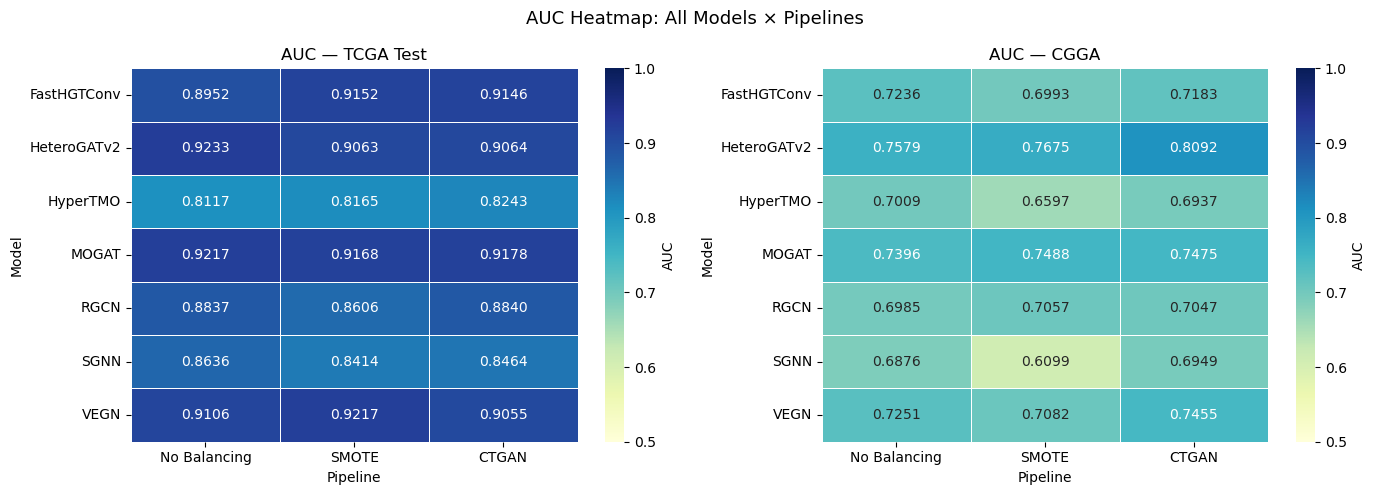

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    # pivot_table with aggfunc='mean' safely handles any duplicate rows
    pivot = (results_df[results_df.Dataset == ds]
             .pivot_table(index='Model', columns='Pipeline',
                          values='AUC', aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
                cbar_kws={'label': 'AUC'})
    ax.set_title(f'AUC — {ds}', fontsize=12)
    ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('AUC Heatmap: All Models × Pipelines', fontsize=13)
plt.tight_layout()
plt.savefig('V11_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Recall Heatmaps — Grade-1 and Grade-0 (TCGA Test)

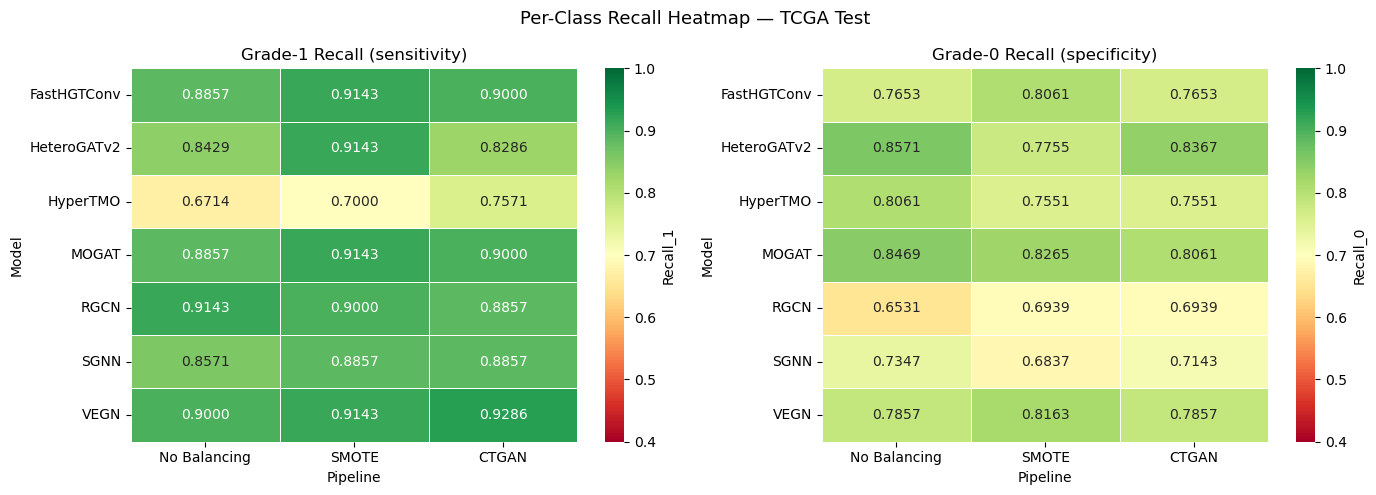

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
        (axes[0], 'Recall_1', 'Grade-1 Recall (sensitivity)'),
        (axes[1], 'Recall_0', 'Grade-0 Recall (specificity)')]:
    pivot = (results_df[results_df.Dataset == 'TCGA Test']
             .pivot_table(index='Model', columns='Pipeline',
                          values=col, aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0,
                cbar_kws={'label': col})
    ax.set_title(title); ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('Per-Class Recall Heatmap — TCGA Test', fontsize=13)
plt.tight_layout()
plt.savefig('V11_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. 5-Fold CV Box Plots

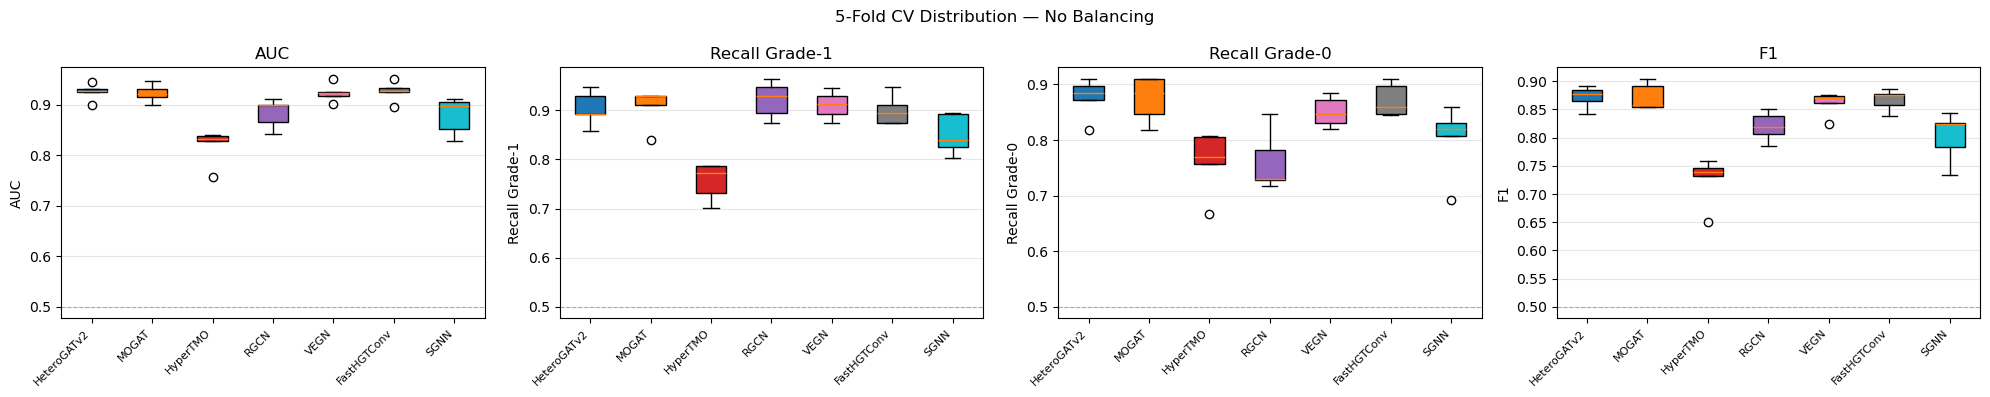

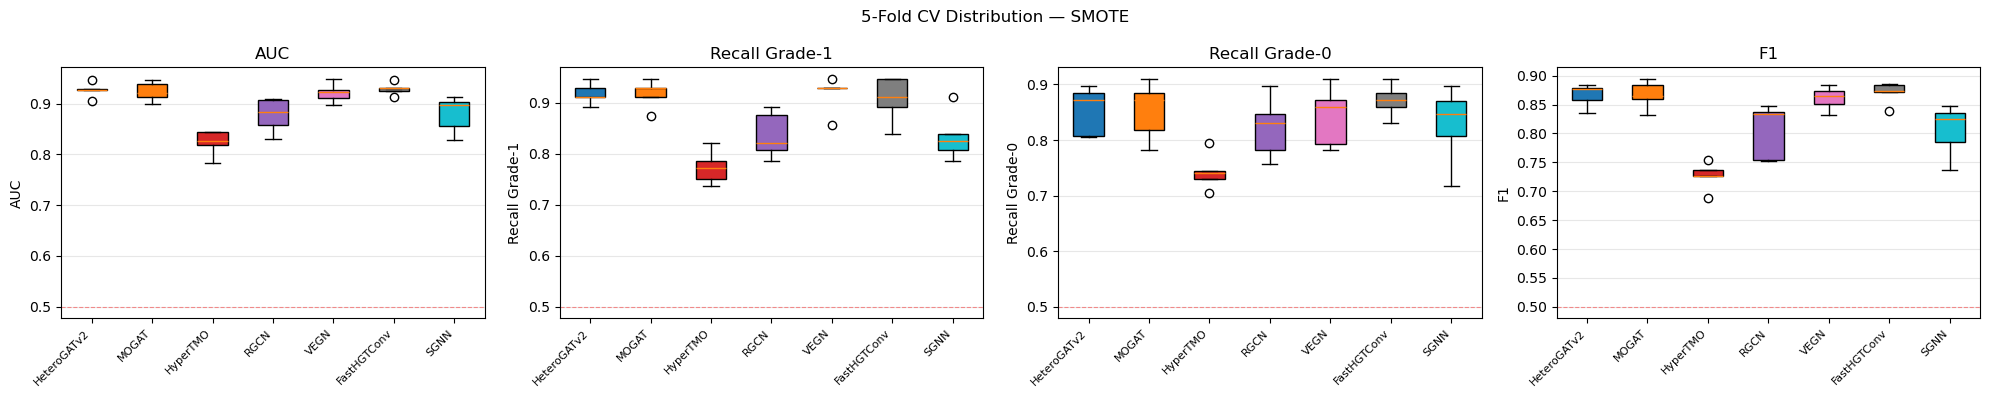

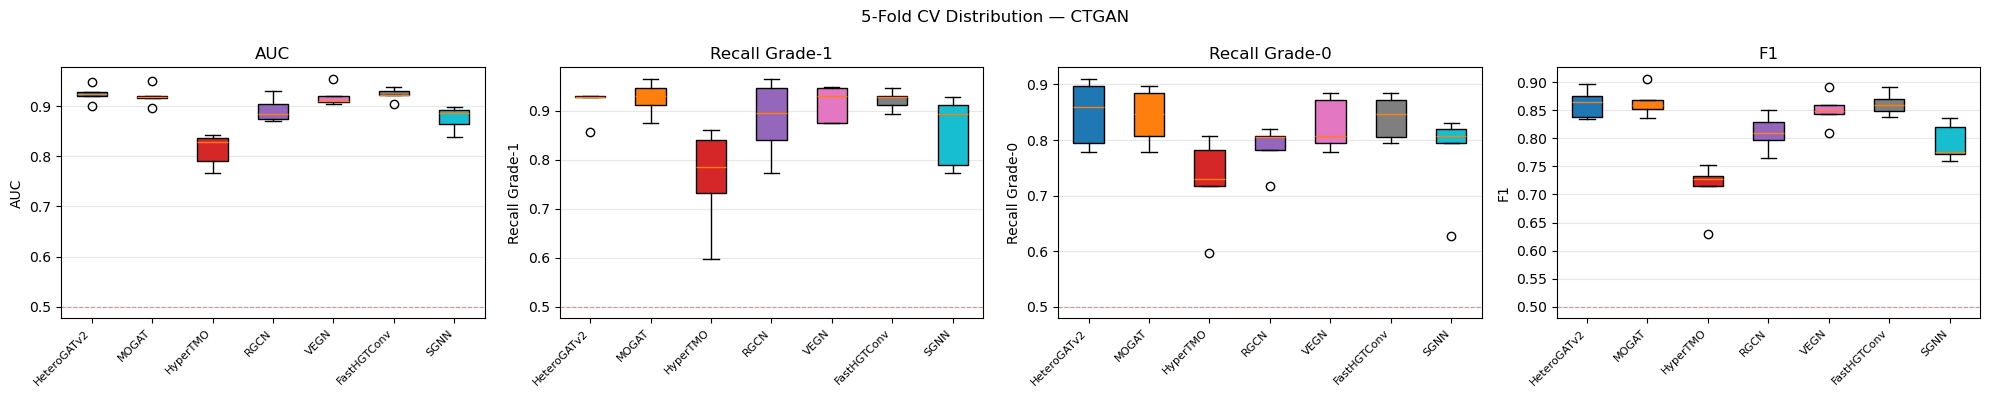

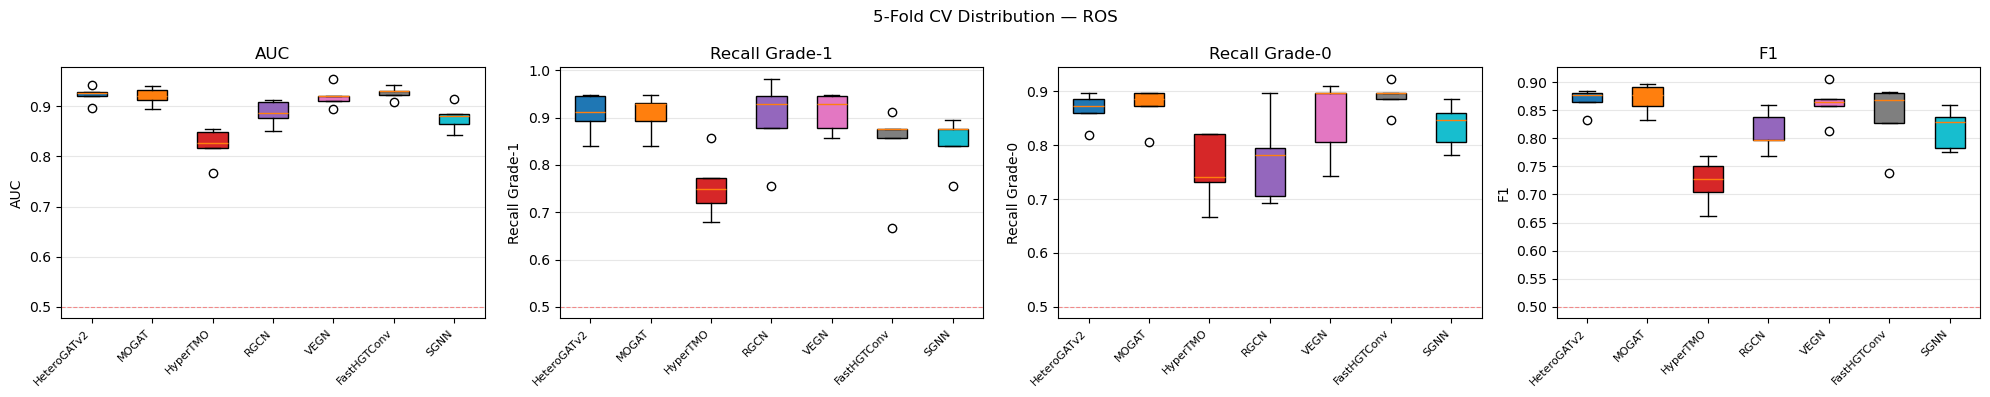

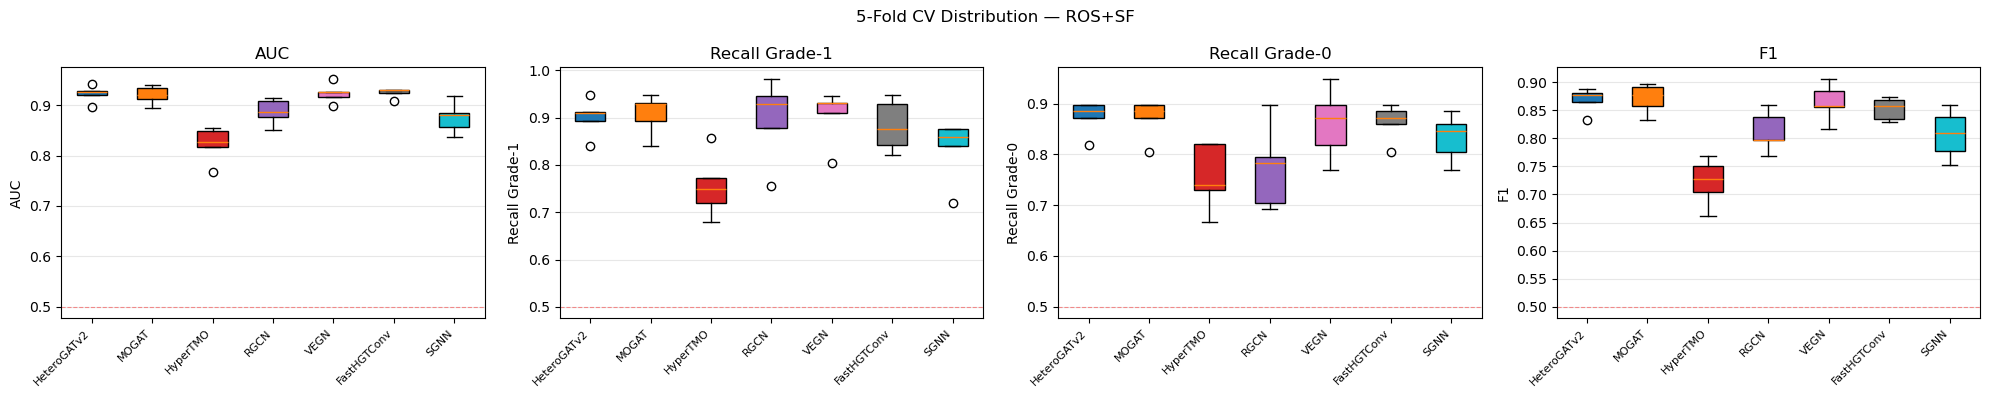

In [25]:
metrics_cv = ['auc', 'recall', 'recall_0', 'f1']
labels_cv  = ['AUC', 'Recall Grade-1', 'Recall Grade-0', 'F1']
model_names = [n for n, _, _ in MODEL_REGISTRY]

for pipe in PIPELINES:
    sub = cv_all[cv_all.Pipeline == pipe]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, met, lab in zip(axes, metrics_cv, labels_cv):
        data = [sub[sub.Model == m][met].values for m in model_names]
        bp = ax.boxplot(data, patch_artist=True, notch=False)
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(model_names)))
        for patch, col in zip(bp['boxes'], colors):
            patch.set_facecolor(col)
        ax.set_xticks(range(1, len(model_names)+1))
        ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel(lab); ax.set_title(lab); ax.grid(axis='y', alpha=0.3)
        ax.axhline(0.5, color='red', ls='--', alpha=0.4, lw=0.8)
    plt.suptitle(f'5-Fold CV Distribution — {pipe}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V11_cv_boxplot_{pipe.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 21. ROC Curve Grid

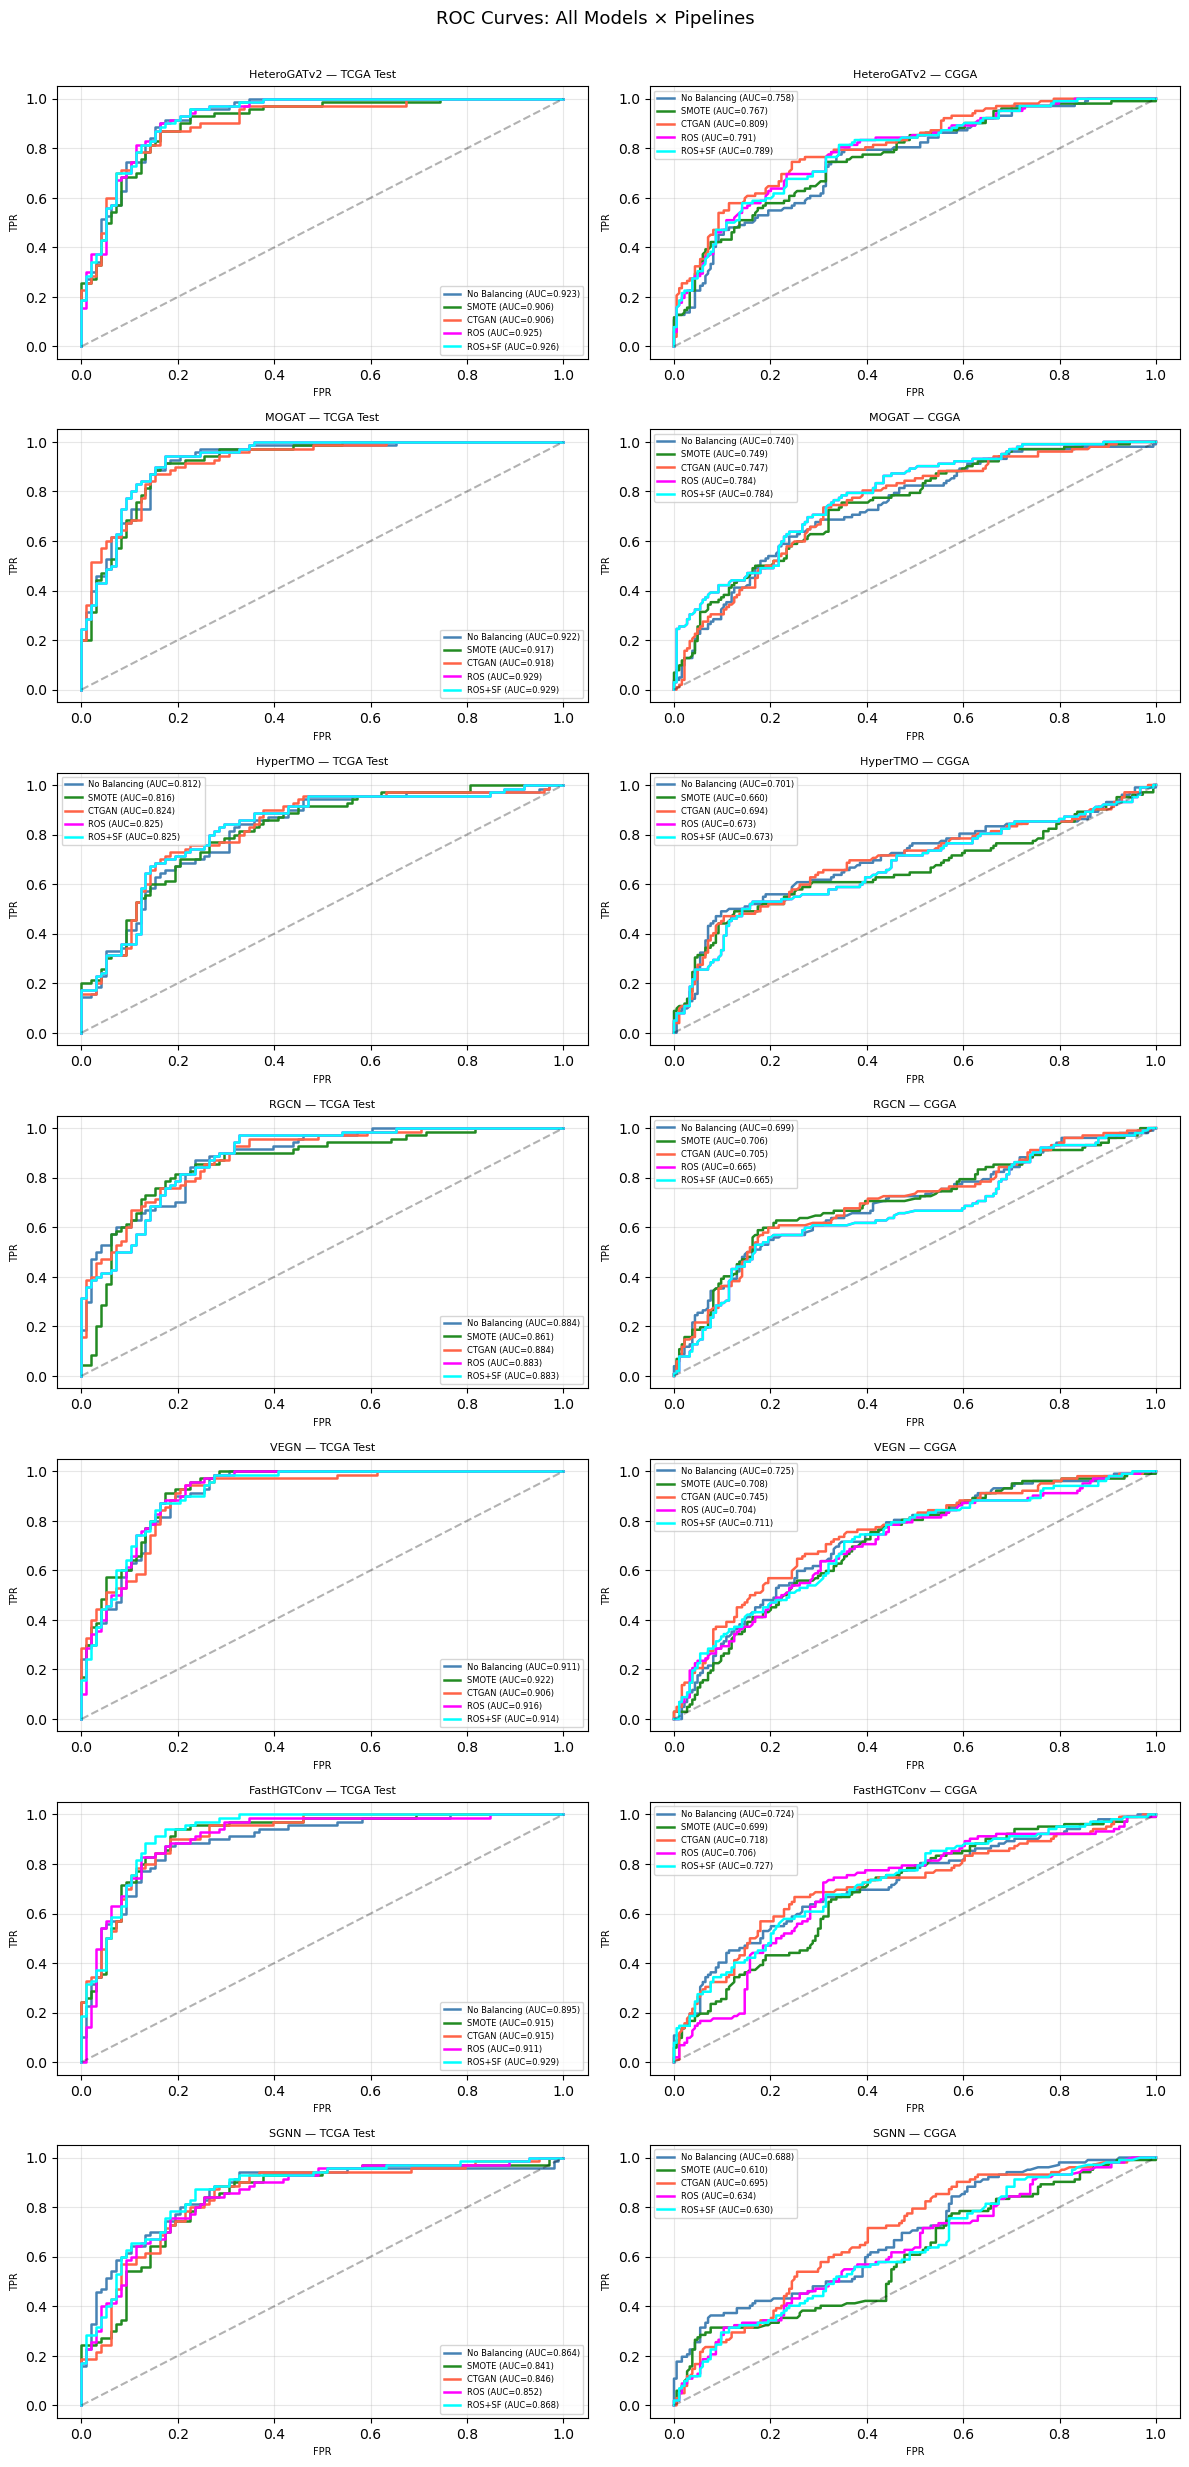

In [27]:
results_full = pd.DataFrame(all_results)
pipe_colors  = {'No Balancing':'steelblue', 'SMOTE':'forestgreen', 'CTGAN':'tomato'}
pipe_colors['ROS'] = 'magenta'
pipe_colors['ROS+SF'] = 'cyan'

fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 3.5*len(model_names)))
for row, mname in enumerate(model_names):
    for col, ds in enumerate(['TCGA Test', 'CGGA']):
        ax = axes[row, col]
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model==mname) &
                                (results_full.Pipeline==pipe) &
                                (results_full.Dataset==ds)]
            if sub.empty: continue
            r = sub.iloc[0]
            fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
            ax.plot(fpr, tpr, color=pipe_colors[pipe], lw=1.8,
                    label=f"{pipe} (AUC={r['auc']:.3f})")
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_title(f"{mname} — {ds}", fontsize=8)
        ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('ROC Curves: All Models × Pipelines', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('V11_roc_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Confusion Matrices

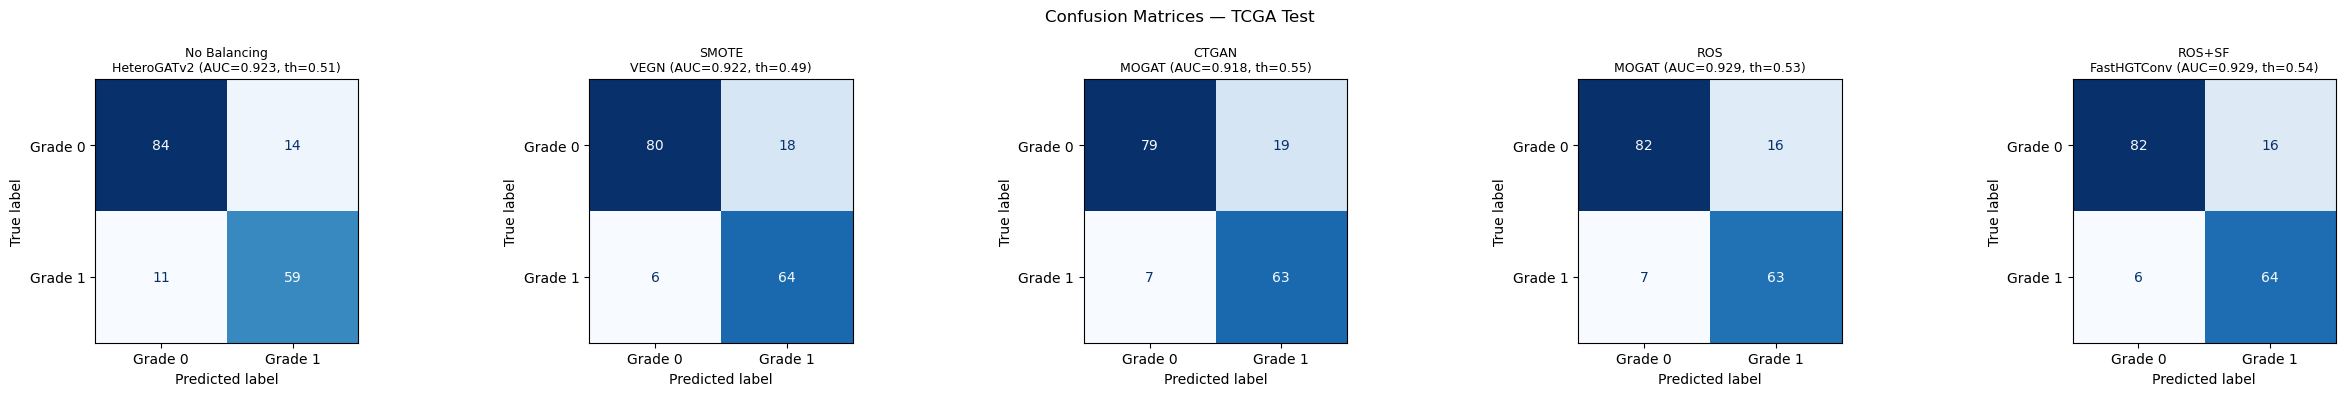

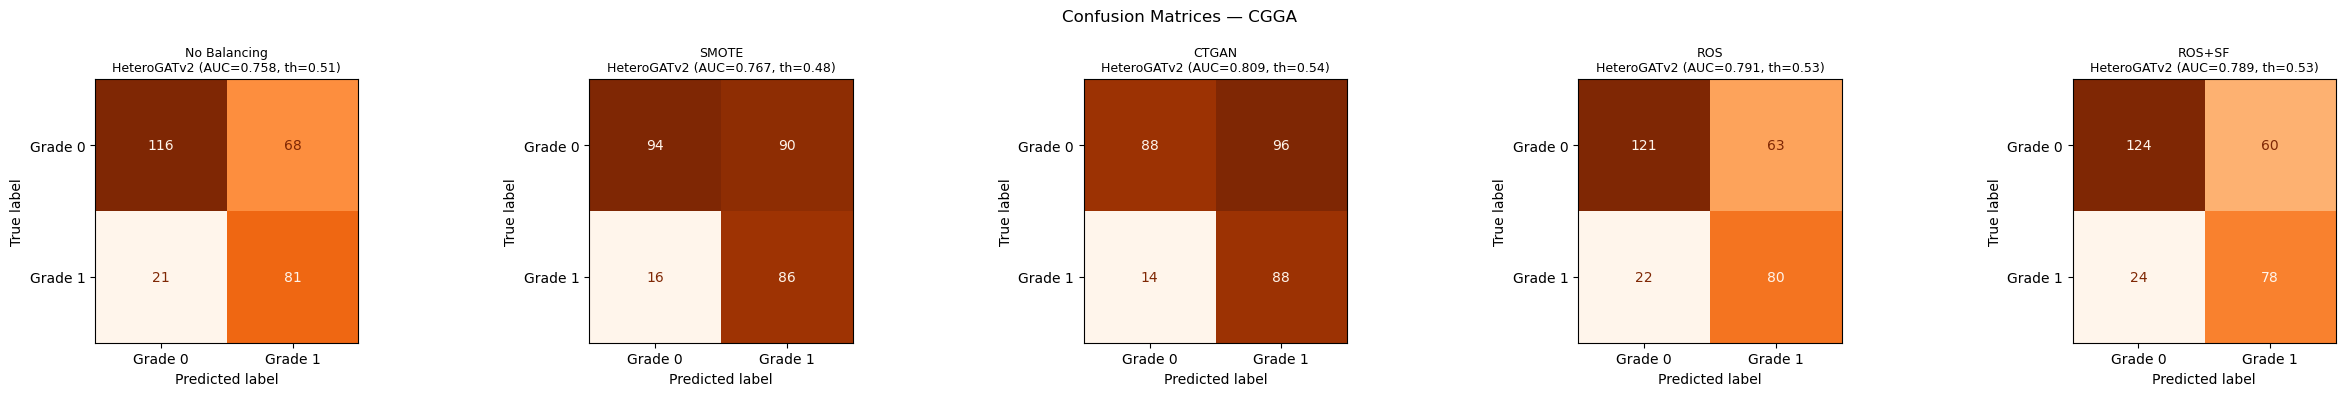

In [29]:
for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, len(PIPELINES), figsize=(5*len(PIPELINES), 4))
    cmap = 'Blues' if ds == 'TCGA Test' else 'Oranges'
    for pi, pipe in enumerate(PIPELINES):
        sub  = results_full[(results_full.Dataset==ds) & (results_full.Pipeline==pipe)]
        if sub.empty: continue
        best = sub.loc[sub['auc'].idxmax()]
        th   = best['threshold']
        preds = (best['probs'] >= th).astype(int)
        cm    = confusion_matrix(best['labels'], preds)
        ConfusionMatrixDisplay(cm, display_labels=['Grade 0','Grade 1']).plot(
            ax=axes[pi], cmap=cmap, colorbar=False)
        axes[pi].set_title(f"{pipe}\n{best['Model']} (AUC={best['auc']:.3f}, th={th:.2f})",
                           fontsize=9)
    plt.suptitle(f'Confusion Matrices — {ds}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V11_cm_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 23. Permutation Feature Importance — Genes + Clinical Features

For every feature (20 gene mutations + 3 clinical: **Age_at_diagnosis, Gender, Race**),
the column is shuffled `n_repeats=10` times and the mean AUC drop is recorded.

- **Gene features** are permuted as binary mutation columns
- **Clinical features** are permuted as continuous/categorical columns in the same way
- The graph is rebuilt from scratch after each permutation so the message-passing
  structure reflects the shuffled values
- Larger AUC drop → feature is more important for classification

In [30]:
# All features subject to permutation importance
CLINICAL_FEATURES = ['Age_at_diagnosis', 'Gender', 'Race']
ALL_FEATURES      = gene_columns + CLINICAL_FEATURES   # 20 genes + 3 clinical = 23 total


def perm_importance_all(model, ref_df, threshold=0.5, n_repeats=10, seed=0):
    """Permutation importance for ALL features (genes + clinical).
    Returns ({feature: mean_auc_drop}, base_auc).
    """
    base_g = to_dev(construct_bipartite_heterograph(ref_df))
    model.eval()
    with torch.no_grad():
        bp = F.softmax(model(base_g), 1)[:, 1].cpu().numpy()
    try:
        base_auc = roc_auc_score(ref_df['Grade'].values, bp)
    except ValueError:
        return {f: 0.0 for f in ALL_FEATURES}, 0.0

    rng = np.random.default_rng(seed)
    out = {}

    for feat in ALL_FEATURES:
        drops = []
        for _ in range(n_repeats):
            df2         = ref_df.copy()
            df2[feat]   = rng.permutation(df2[feat].values)  # shuffle this feature
            g2          = to_dev(construct_bipartite_heterograph(df2))
            with torch.no_grad():
                pp = F.softmax(model(g2), 1)[:, 1].cpu().numpy()
            try:
                drops.append(base_auc - roc_auc_score(ref_df['Grade'].values, pp))
            except ValueError:
                drops.append(0.0)
        out[feat] = float(np.mean(drops))

    clear_pp_cache()
    return out, base_auc


print("Computing permutation importance for genes + clinical features...")
print(f"Features: {len(ALL_FEATURES)} total ({len(gene_columns)} genes + {len(CLINICAL_FEATURES)} clinical)")
print(f"Models: {len(MODEL_REGISTRY)} × Pipelines: {len(PIPELINES)} = {len(MODEL_REGISTRY)*len(PIPELINES)} combinations")
print(f"Repeats per feature: 10  →  Total graph builds: {len(ALL_FEATURES)*10*len(MODEL_REGISTRY)*len(PIPELINES):,}")

imp_records = []
for mname, MCls, _ in MODEL_REGISTRY:
    for pipe in PIPELINES:
        model = all_models.get((mname, pipe))
        if model is None: continue
        th        = all_thresholds.get((mname, pipe), 0.5)
        imp, base = perm_importance_all(model, test_df, threshold=th)
        for feat, drop in imp.items():
            imp_records.append({
                'Model':        mname,
                'Pipeline':     pipe,
                'Feature':      feat,
                'Feature_Type': 'Clinical' if feat in CLINICAL_FEATURES else 'Gene',
                'AUC_Drop':     drop,
                'Base_AUC':     base,
            })
        print(f"  {mname}/{pipe}  base={base:.4f}")

imp_df = pd.DataFrame(imp_records)
imp_df.to_csv('V11_feature_importance.csv', index=False)
print(f"\nDone. Saved V11_feature_importance.csv ({len(imp_df)} rows)")

Computing permutation importance for genes + clinical features...
Features: 23 total (20 genes + 3 clinical)
Models: 7 × Pipelines: 5 = 35 combinations
Repeats per feature: 10  →  Total graph builds: 8,050
  HeteroGATv2/No Balancing  base=0.9233
  HeteroGATv2/SMOTE  base=0.9063
  HeteroGATv2/CTGAN  base=0.9064
  HeteroGATv2/ROS  base=0.9254
  HeteroGATv2/ROS+SF  base=0.9258
  MOGAT/No Balancing  base=0.9217
  MOGAT/SMOTE  base=0.9168
  MOGAT/CTGAN  base=0.9178
  MOGAT/ROS  base=0.9287
  MOGAT/ROS+SF  base=0.9287
  HyperTMO/No Balancing  base=0.8117
  HyperTMO/SMOTE  base=0.8165
  HyperTMO/CTGAN  base=0.8243
  HyperTMO/ROS  base=0.8254
  HyperTMO/ROS+SF  base=0.8254
  RGCN/No Balancing  base=0.8837
  RGCN/SMOTE  base=0.8606
  RGCN/CTGAN  base=0.8840
  RGCN/ROS  base=0.8831
  RGCN/ROS+SF  base=0.8831
  VEGN/No Balancing  base=0.9106
  VEGN/SMOTE  base=0.9217
  VEGN/CTGAN  base=0.9055
  VEGN/ROS  base=0.9159
  VEGN/ROS+SF  base=0.9140
  FastHGTConv/No Balancing  base=0.8952
  FastHGTConv/

## 24. Feature Importance Plots — Genes + Clinical

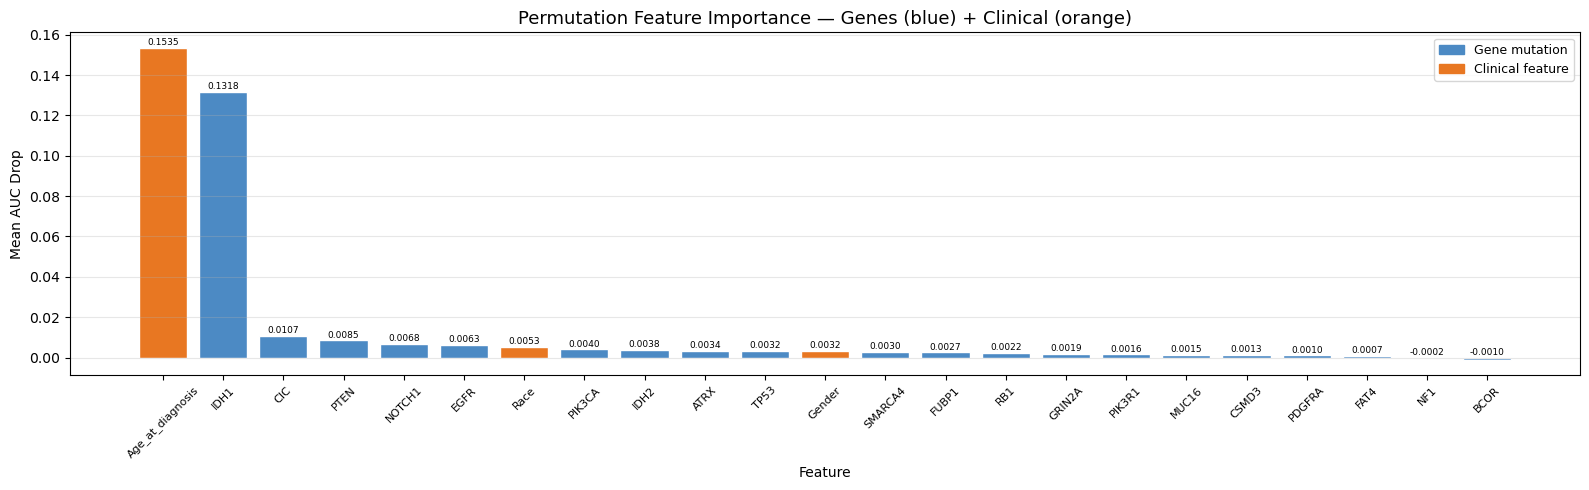

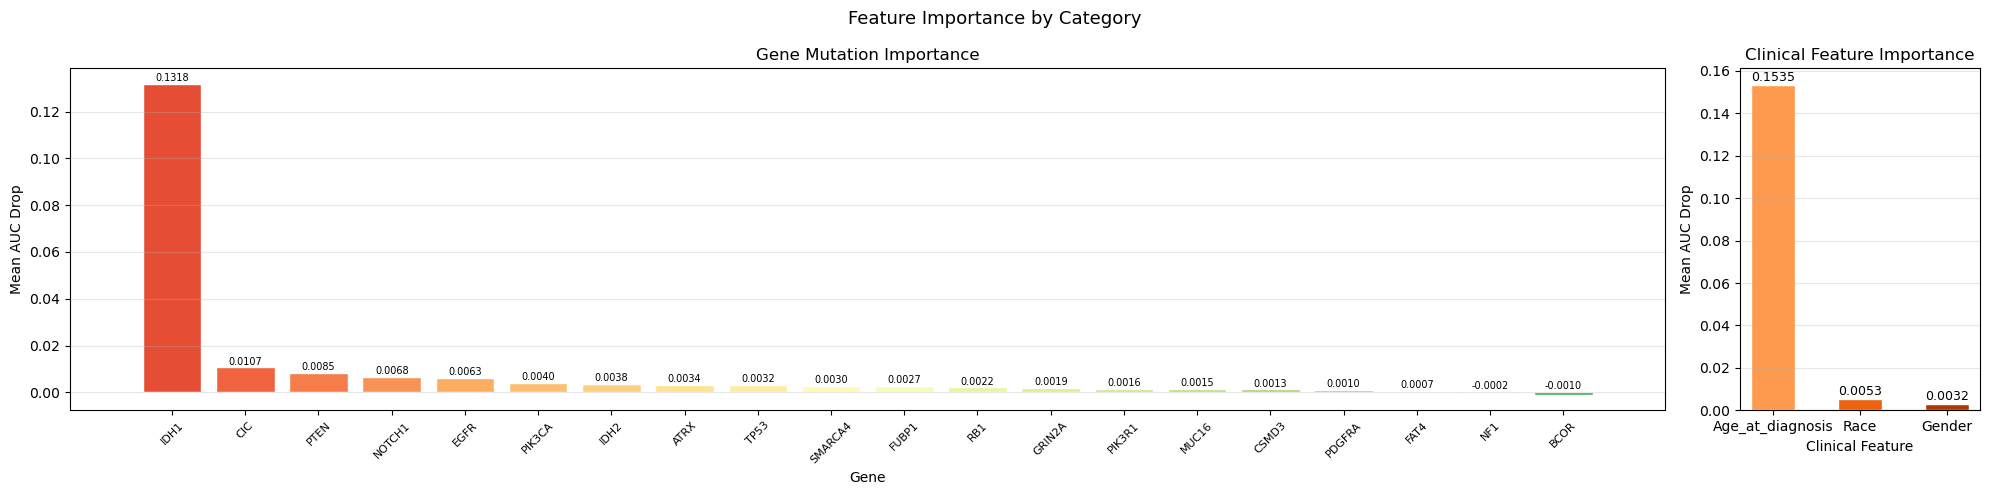

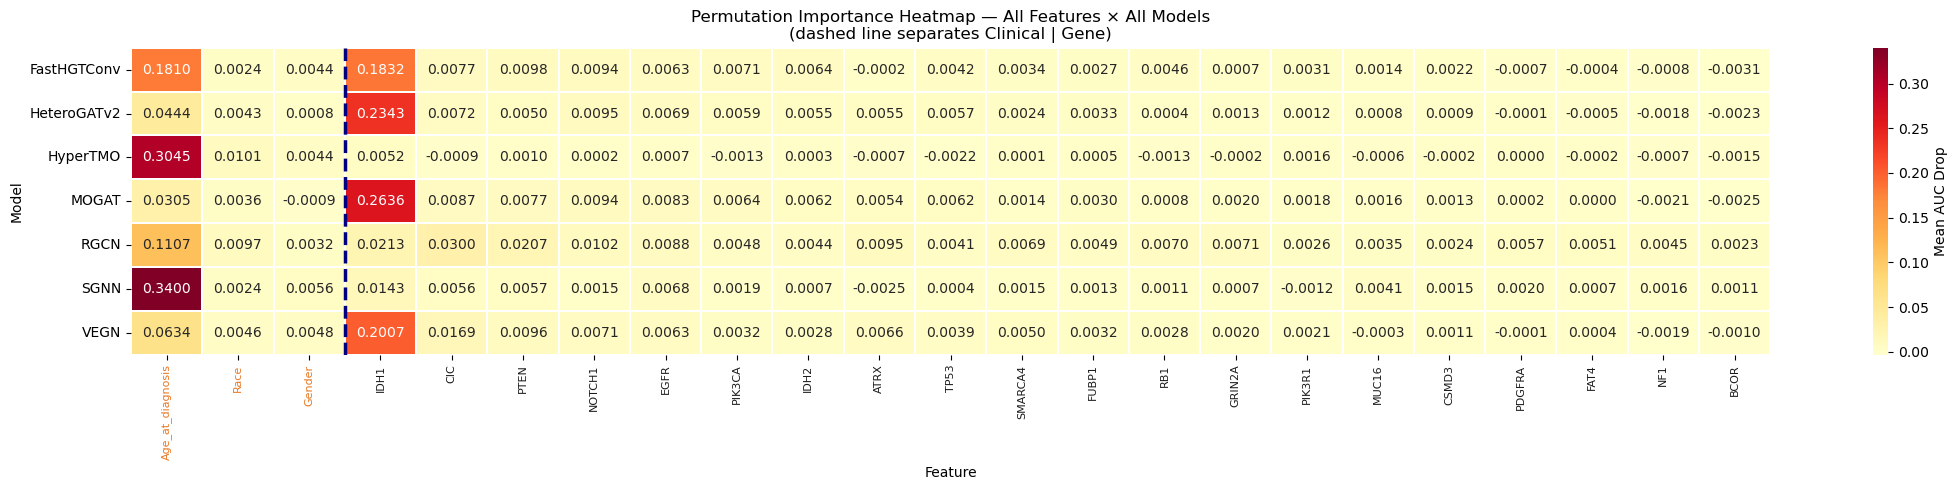

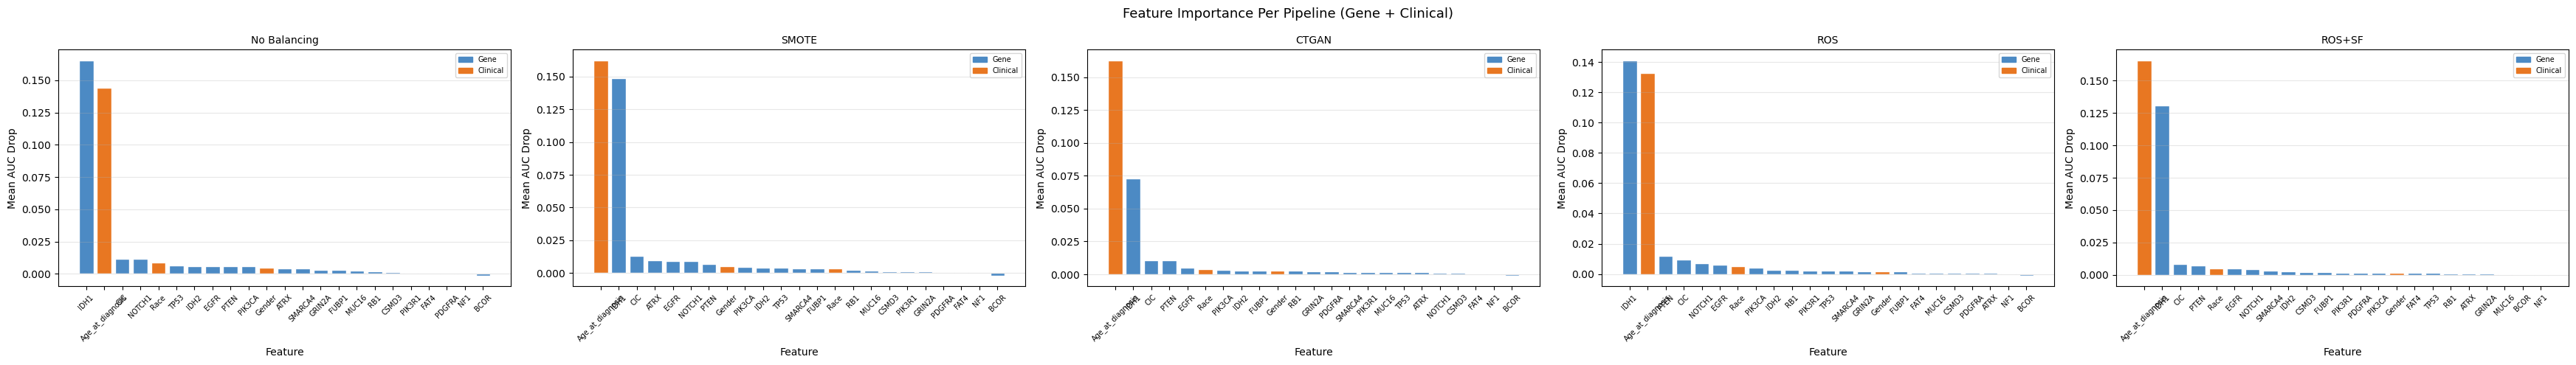


OVERALL FEATURE IMPORTANCE RANKING (mean AUC drop across all models & pipelines)
   1. [CLINICAL]  Age_at_diagnosis      0.1535
   2. [GENE]     IDH1                  0.1318
   3. [GENE]     CIC                   0.0107
   4. [GENE]     PTEN                  0.0085
   5. [GENE]     NOTCH1                0.0068
   6. [GENE]     EGFR                  0.0063
   7. [CLINICAL]  Race                  0.0053
   8. [GENE]     PIK3CA                0.0040
   9. [GENE]     IDH2                  0.0038
  10. [GENE]     ATRX                  0.0034
  11. [GENE]     TP53                  0.0032
  12. [CLINICAL]  Gender                0.0032
  13. [GENE]     SMARCA4               0.0030
  14. [GENE]     FUBP1                 0.0027
  15. [GENE]     RB1                   0.0022
  16. [GENE]     GRIN2A                0.0019
  17. [GENE]     PIK3R1                0.0016
  18. [GENE]     MUC16                 0.0015
  19. [GENE]     CSMD3                 0.0013
  20. [GENE]     PDGFRA                0.

In [32]:
# ── Aggregate: mean AUC drop per feature across all models & pipelines ──
mean_imp = (imp_df.groupby(['Feature','Feature_Type'])['AUC_Drop']
            .mean()
            .reset_index()
            .sort_values('AUC_Drop', ascending=False)
            .reset_index(drop=True))

# Colour: orange for clinical, steelblue for gene
bar_colors = ['#E87722' if t == 'Clinical' else '#4C8AC4'
              for t in mean_imp['Feature_Type']]

# ─────────────────────────────────────────────────────────────────
# PLOT A: Combined bar chart — all 23 features, colour-coded by type
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(mean_imp['Feature'], mean_imp['AUC_Drop'], color=bar_colors, edgecolor='white')
ax.set_xlabel('Feature'); ax.set_ylabel('Mean AUC Drop')
ax.set_title('Permutation Feature Importance — Genes (blue) + Clinical (orange)', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, mean_imp['AUC_Drop']):
    ax.text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
            f'{v:.4f}', ha='center', va='bottom', fontsize=6.5)

# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C8AC4', label='Gene mutation'),
                    Patch(color='#E87722', label='Clinical feature')],
           fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('V11_feat_importance_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT B: Side-by-side — Gene panel | Clinical panel
# ─────────────────────────────────────────────────────────────────
gene_imp = mean_imp[mean_imp.Feature_Type == 'Gene'].copy()
clin_imp = mean_imp[mean_imp.Feature_Type == 'Clinical'].copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 5),
                          gridspec_kw={'width_ratios': [len(gene_imp), len(clin_imp)]})

# Gene panel
gcols = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(gene_imp)))
b1 = axes[0].bar(gene_imp['Feature'], gene_imp['AUC_Drop'], color=gcols, edgecolor='white')
axes[0].set_title('Gene Mutation Importance', fontsize=12)
axes[0].set_xlabel('Gene'); axes[0].set_ylabel('Mean AUC Drop')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].grid(axis='y', alpha=0.3)
for b, v in zip(b1, gene_imp['AUC_Drop']):
    axes[0].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=7)

# Clinical panel
ccols = plt.cm.Oranges(np.linspace(0.45, 0.85, len(clin_imp)))
b2 = axes[1].bar(clin_imp['Feature'], clin_imp['AUC_Drop'], color=ccols, edgecolor='white',
                  width=0.5)
axes[1].set_title('Clinical Feature Importance', fontsize=12)
axes[1].set_xlabel('Clinical Feature'); axes[1].set_ylabel('Mean AUC Drop')
axes[1].tick_params(axis='x', rotation=0, labelsize=10)
axes[1].grid(axis='y', alpha=0.3)
for b, v in zip(b2, clin_imp['AUC_Drop']):
    axes[1].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Feature Importance by Category', fontsize=13)
plt.tight_layout()
plt.savefig('V11_feat_importance_sidebyside.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT C: Heatmap — all 23 features × 7 models (averaged over pipelines)
# ─────────────────────────────────────────────────────────────────
# Column order: clinical first, then genes sorted by mean importance
col_order = (list(clin_imp['Feature']) +
             list(gene_imp.sort_values('AUC_Drop', ascending=False)['Feature']))

heat = (imp_df.groupby(['Model','Feature'])['AUC_Drop']
        .mean()
        .unstack('Feature')
        .reindex(columns=col_order))

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.35,
            ax=ax, cbar_kws={'label': 'Mean AUC Drop'})

# Vertical separator between clinical and gene columns
ax.axvline(x=len(CLINICAL_FEATURES), color='navy', lw=2.5, ls='--')

ax.set_title('Permutation Importance Heatmap — All Features × All Models\n'
             '(dashed line separates Clinical | Gene)', fontsize=12)

ax.set_xlabel('Feature'); ax.set_ylabel('Model')

# Colour x-tick labels by type
for tick, feat in zip(ax.get_xticklabels(), col_order):
    tick.set_color('#E87722' if feat in CLINICAL_FEATURES else '#1a1a1a')
    tick.set_fontsize(8)

plt.tight_layout()
plt.savefig('V11_feat_importance_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT D: Per-pipeline importance — clinical vs gene
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(PIPELINES), figsize=(7 * len(PIPELINES), 5))
for pi, pipe in enumerate(PIPELINES):
    sub = (imp_df[imp_df.Pipeline == pipe]
           .groupby(['Feature','Feature_Type'])['AUC_Drop'].mean()
           .reset_index()
           .sort_values('AUC_Drop', ascending=False))
    colors_p = ['#E87722' if t == 'Clinical' else '#4C8AC4'
                for t in sub['Feature_Type']]
    axes[pi].bar(sub['Feature'], sub['AUC_Drop'], color=colors_p, edgecolor='white')
    axes[pi].set_title(f'{pipe}', fontsize=10)
    axes[pi].set_xlabel('Feature'); axes[pi].set_ylabel('Mean AUC Drop')
    axes[pi].tick_params(axis='x', rotation=45, labelsize=7)
    axes[pi].grid(axis='y', alpha=0.3)
    axes[pi].legend(handles=[Patch(color='#4C8AC4', label='Gene'),
                               Patch(color='#E87722', label='Clinical')],
                     fontsize=7)
plt.suptitle('Feature Importance Per Pipeline (Gene + Clinical)', fontsize=13)
plt.tight_layout()
plt.savefig('V11_feat_importance_per_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────
print("\nOVERALL FEATURE IMPORTANCE RANKING (mean AUC drop across all models & pipelines)")
print("="*65)
for i, row in mean_imp.iterrows():
    tag = '[CLINICAL]' if row['Feature_Type'] == 'Clinical' else '[GENE]   '
    print(f"  {i+1:2d}. {tag}  {row['Feature']:20s}  {row['AUC_Drop']:.4f}")

print(f"\nClinical features summary:")
for _, row in clin_imp.iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

print(f"\nTop-5 gene features:")
for _, row in gene_imp.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

## 25. GAT & MOGAT Attention Weights

**HeteroGATv2**: gene→patient GATv2 attention.  
**MOGAT**: same gene→patient GATv2 genomic attention **plus** the fusion gate values showing how much each patient relies on the genomic vs clinical pathway.


Attention: HeteroGATv2 / No Balancing


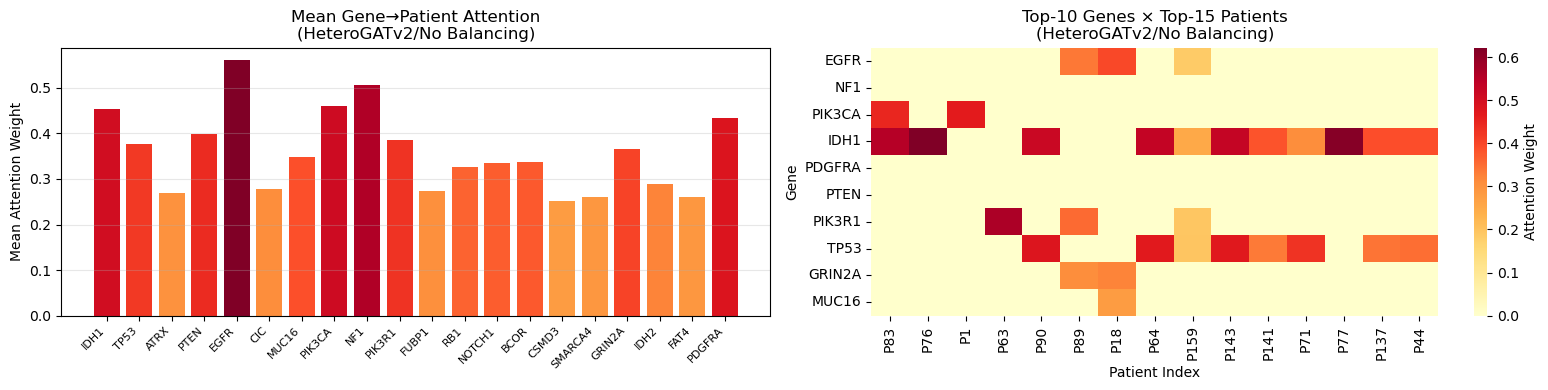


Attention: MOGAT / No Balancing
  MOGAT has no get_attn_weights — skipping.


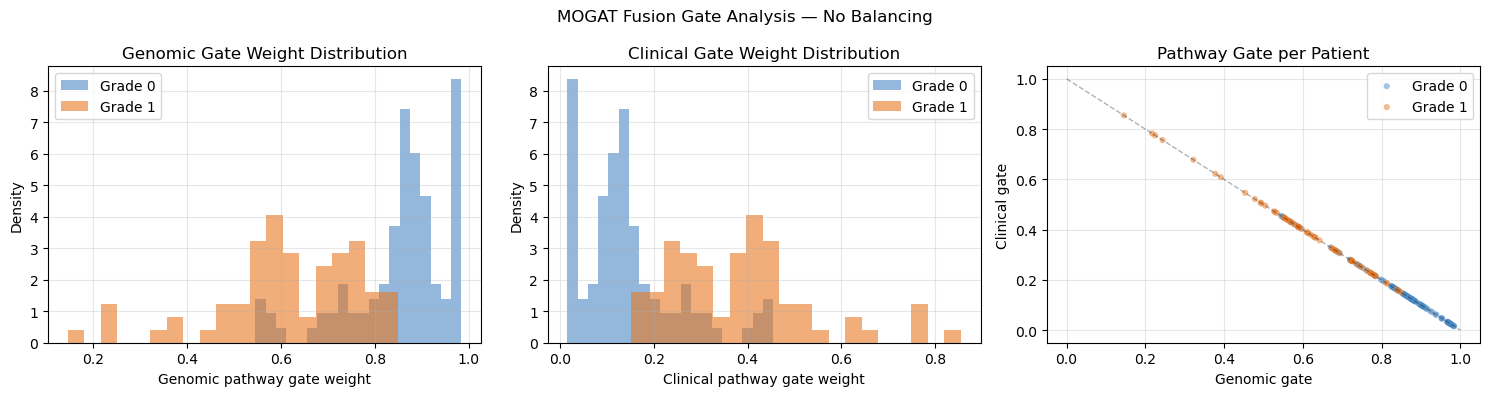


Attention: HeteroGATv2 / SMOTE


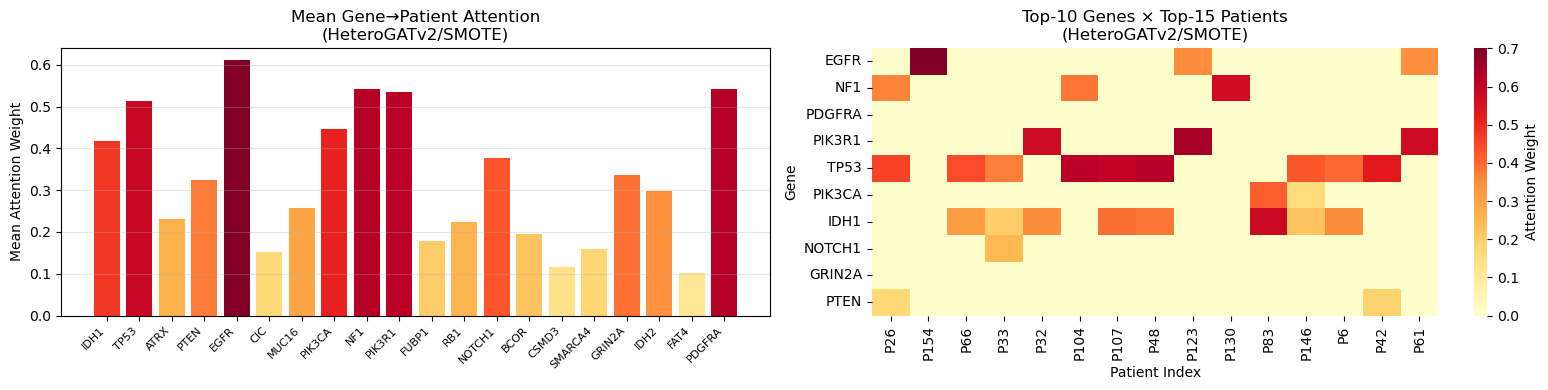


Attention: MOGAT / SMOTE
  MOGAT has no get_attn_weights — skipping.


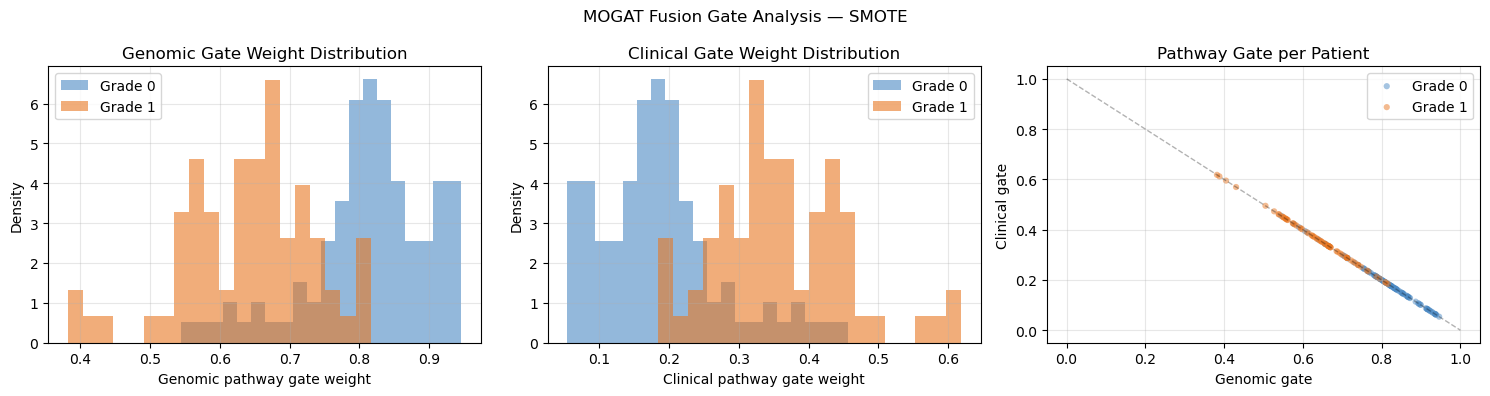


Attention: HeteroGATv2 / CTGAN


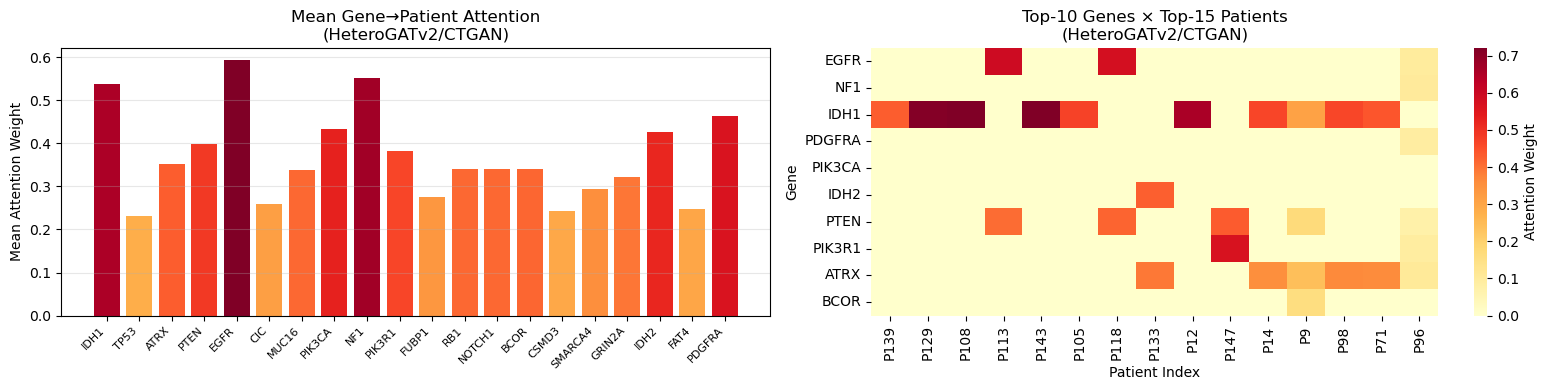


Attention: MOGAT / CTGAN
  MOGAT has no get_attn_weights — skipping.


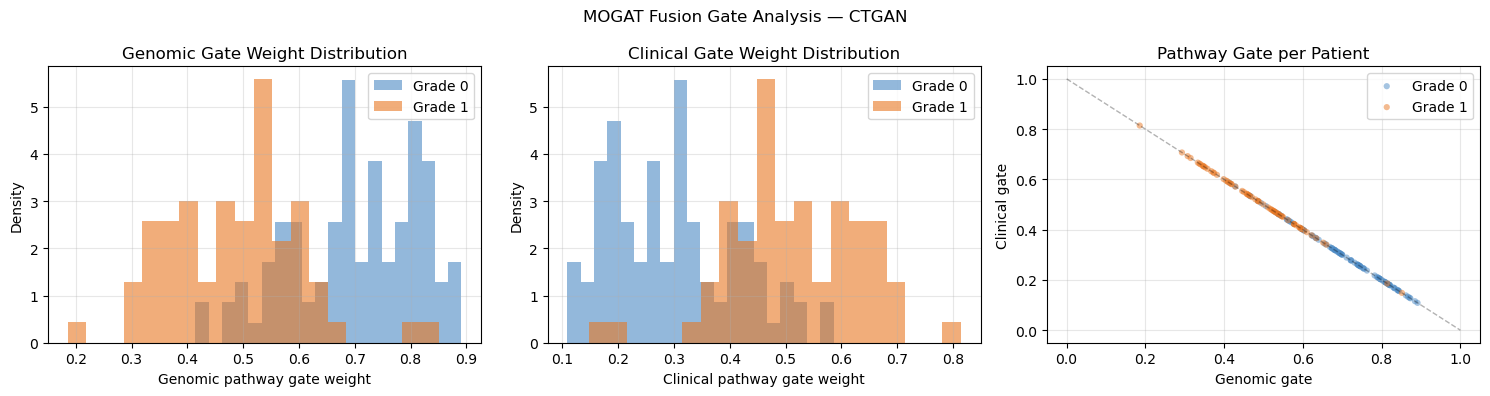


Attention: HeteroGATv2 / ROS


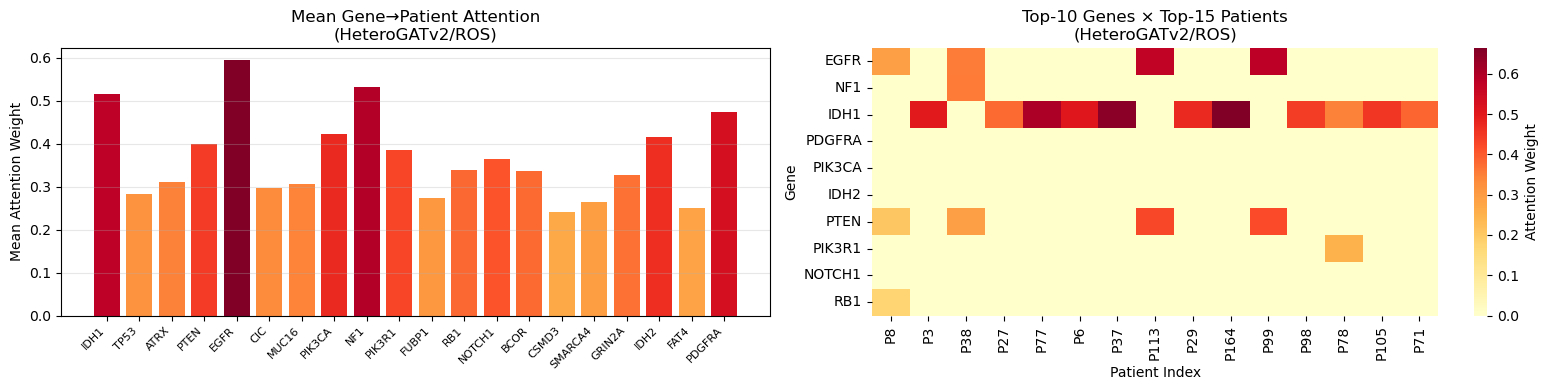


Attention: MOGAT / ROS
  MOGAT has no get_attn_weights — skipping.


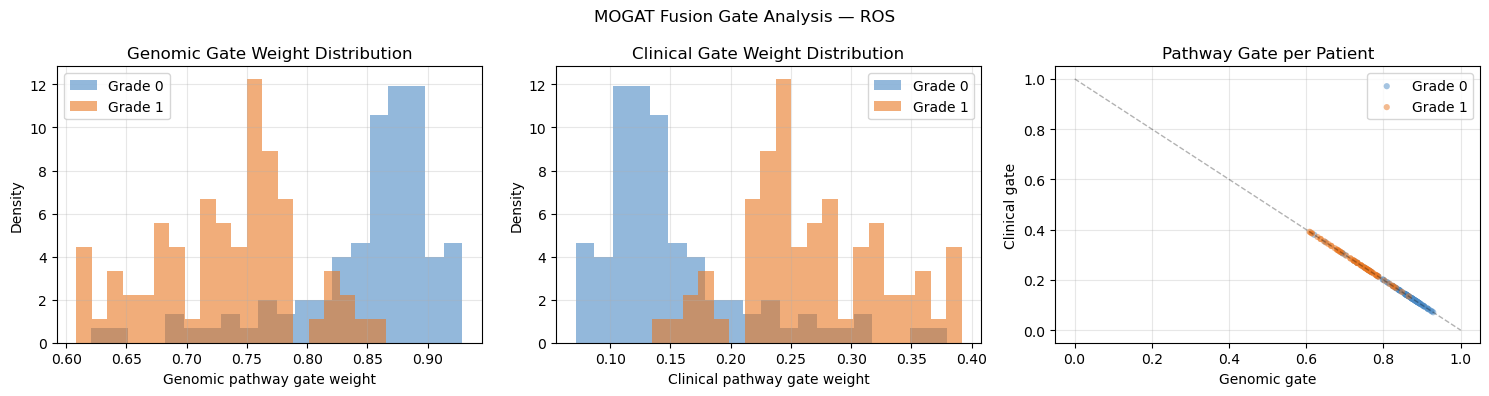


Attention: HeteroGATv2 / ROS+SF


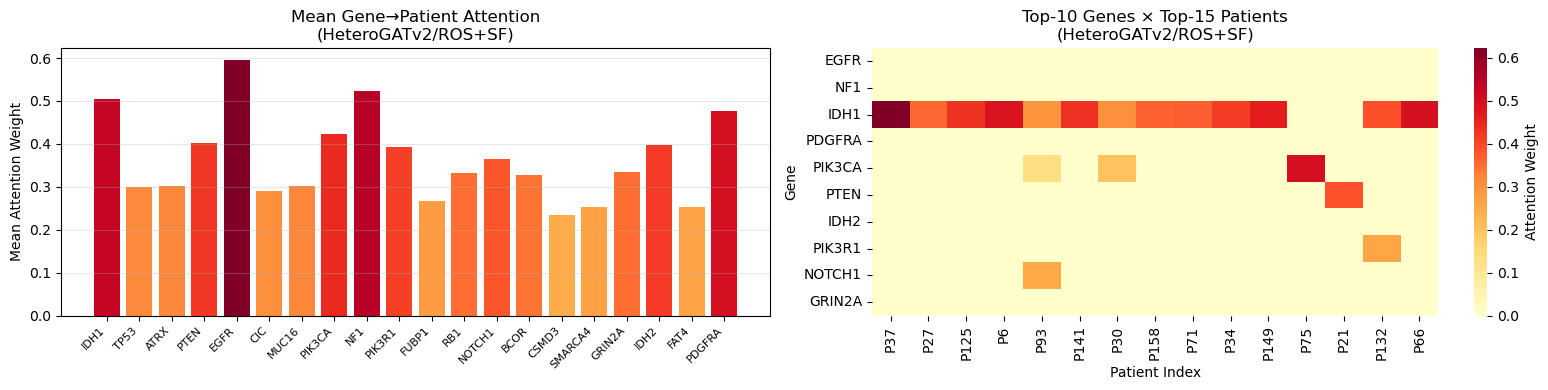


Attention: MOGAT / ROS+SF
  MOGAT has no get_attn_weights — skipping.


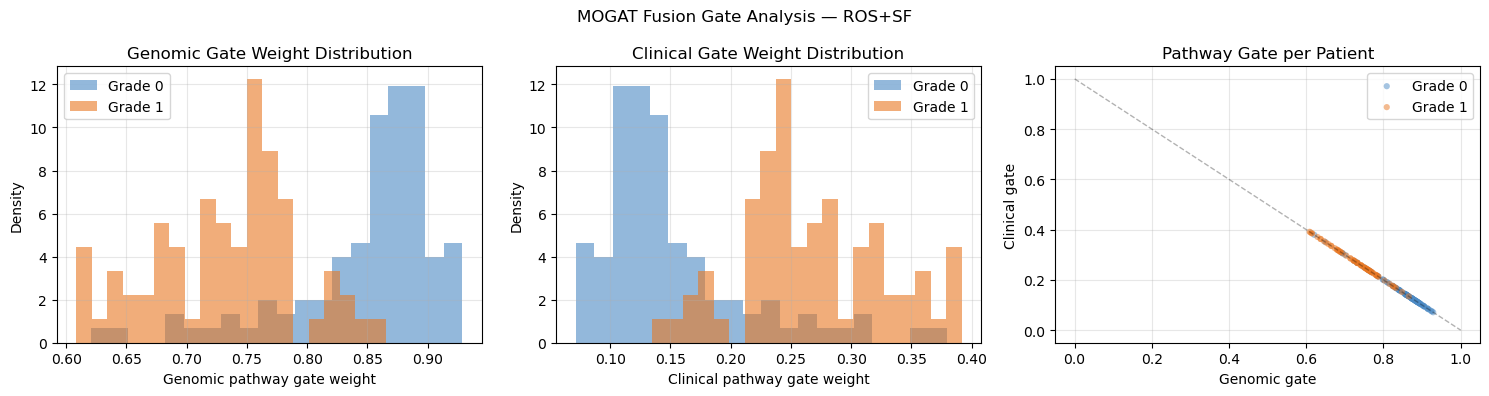

In [33]:
def plot_gene_attention(model, graph, ref_df, title):
    """Visualise gene->patient attention for any model that exposes get_attn_weights().
    For MOGAT the function also prints the fusion gate split (printed inside get_attn_weights).
    """
    model.eval()
    if not hasattr(model, 'get_attn_weights'):
        print(f"  {type(model).__name__} has no get_attn_weights — skipping.")
        return
    try:
        eidx, weights = model.get_attn_weights(graph)
    except Exception as e:
        print(f"  Attention extraction failed: {e}"); return

    gene_ids = eidx[0].cpu().numpy()
    pat_ids  = eidx[1].cpu().numpy()
    w        = weights.cpu().numpy()

    # Mean attention weight per gene (averaged over all edges touching that gene)
    gene_attn = np.zeros(NUM_GENES); gene_cnt = np.zeros(NUM_GENES)
    for g, wt in zip(gene_ids, w):
        if 0 <= g < NUM_GENES:
            gene_attn[g] += wt; gene_cnt[g] += 1
    gene_cnt  = np.maximum(gene_cnt, 1)
    gene_attn /= gene_cnt

    # Top-10 genes and top-15 patients by total received attention
    n_pat = ref_df.shape[0]
    top_g  = np.argsort(gene_attn)[::-1][:10]
    pat_wsum = np.zeros(n_pat)
    for g, p, wt in zip(gene_ids, pat_ids, w):
        if 0 <= p < n_pat: pat_wsum[p] += wt
    top_p = np.argsort(pat_wsum)[::-1][:15]

    mat = np.zeros((len(top_g), len(top_p)))
    for g_loc, g in enumerate(top_g):
        for p_loc, p in enumerate(top_p):
            mask = (gene_ids == g) & (pat_ids == p)
            if mask.any(): mat[g_loc, p_loc] = w[mask].mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Bar chart: mean attention per gene
    norm_a = gene_attn / (gene_attn.max() + 1e-9)
    axes[0].bar(gene_columns, gene_attn, color=plt.cm.YlOrRd(norm_a))
    axes[0].set_xticklabels(gene_columns, rotation=45, ha='right', fontsize=8)
    axes[0].set_title(f'Mean Gene→Patient Attention\n({title})')
    axes[0].set_ylabel('Mean Attention Weight'); axes[0].grid(axis='y', alpha=0.3)

    # Heatmap: top genes × top patients
    sns.heatmap(mat, ax=axes[1], cmap='YlOrRd',
                xticklabels=[f'P{p}' for p in top_p],
                yticklabels=[gene_columns[g] for g in top_g],
                cbar_kws={'label': 'Attention Weight'})
    axes[1].set_title(f'Top-10 Genes × Top-15 Patients\n({title})')
    axes[1].set_xlabel('Patient Index'); axes[1].set_ylabel('Gene')

    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V11_attn_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── MOGAT: also show per-patient fusion gate distribution ─────────
def plot_mogat_fusion_gate(model, graph, ref_df, title):
    """Show the distribution of genomic vs clinical pathway weights
    (the learned soft gate) across all patients."""
    model.eval()
    if not isinstance(model, MOGAT):
        return
    with torch.no_grad():
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(model.pg(graph['Patient'].x))
        hgg = F.relu(model.gg(graph['Gene'].x))
        hpg_out = F.leaky_relu(model.gat((hgg, hpg), e), 0.2)
        hpc     = model.mlp(F.relu(model.pc(graph['Patient'].x)))
        gate_w  = torch.softmax(model.gate(torch.cat([hpg_out, hpc], -1)), dim=-1)
        gw      = gate_w.cpu().numpy()   # [n_patients, 2]  col0=genomic, col1=clinical

    labels  = ref_df['Grade'].values
    grades  = ['Grade 0', 'Grade 1']
    colors  = ['#4C8AC4', '#E87722']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram of genomic gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[0].hist(gw[mask, 0], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[0].set_xlabel('Genomic pathway gate weight'); axes[0].set_ylabel('Density')
    axes[0].set_title('Genomic Gate Weight Distribution'); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Histogram of clinical gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[1].hist(gw[mask, 1], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[1].set_xlabel('Clinical pathway gate weight'); axes[1].set_ylabel('Density')
    axes[1].set_title('Clinical Gate Weight Distribution'); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Scatter: genomic vs clinical gate per patient, coloured by grade
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[2].scatter(gw[mask, 0], gw[mask, 1], c=color, label=lbl,
                         alpha=0.5, s=20, edgecolors='none')
    axes[2].plot([0,1],[1,0],'k--', alpha=0.3, lw=1)   # gate sums to 1
    axes[2].set_xlabel('Genomic gate'); axes[2].set_ylabel('Clinical gate')
    axes[2].set_title('Pathway Gate per Patient'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(f'MOGAT Fusion Gate Analysis — {title}', fontsize=12)
    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V11_mogat_gate_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Run for HeteroGATv2 and MOGAT across all pipelines ───────────
for pipe in PIPELINES:
    for mname in ['HeteroGATv2', 'MOGAT']:
        m = all_models.get((mname, pipe))
        if m is None: continue
        print(f"\nAttention: {mname} / {pipe}")
        plot_gene_attention(m, test_graph, test_df, f"{mname}/{pipe}")
        if mname == 'MOGAT':
            plot_mogat_fusion_gate(m, test_graph, test_df, f"{pipe}")

## 26. Classification Reports — Best Model Overall

In [34]:
for ds in ['TCGA Test','CGGA']:
    sub  = results_full[results_full.Dataset==ds]
    best = sub.loc[sub['auc'].idxmax()]
    th   = best['threshold']
    preds  = (best['probs'] >= th).astype(int)
    labels = best['labels']
    print(f"{'='*65}")
    print(f"Best on {ds}: {best['Model']} / {best['Pipeline']}")
    print(f"AUC={best['auc']:.4f}  Threshold={th:.3f}")
    print(classification_report(labels, preds, target_names=['Grade 0','Grade 1']))

Best on TCGA Test: FastHGTConv / ROS+SF
AUC=0.9294  Threshold=0.538
              precision    recall  f1-score   support

     Grade 0       0.93      0.84      0.88        98
     Grade 1       0.80      0.91      0.85        70

    accuracy                           0.87       168
   macro avg       0.87      0.88      0.87       168
weighted avg       0.88      0.87      0.87       168

Best on CGGA: HeteroGATv2 / CTGAN
AUC=0.8092  Threshold=0.536
              precision    recall  f1-score   support

     Grade 0       0.86      0.48      0.62       184
     Grade 1       0.48      0.86      0.62       102

    accuracy                           0.62       286
   macro avg       0.67      0.67      0.62       286
weighted avg       0.73      0.62      0.62       286



## 27. Save Results

In [35]:
# import os
# os.makedirs('saved_models_v10', exist_ok=True)
# for (mname, pipe), model in all_models.items():
#     fn = f"saved_models_v10/{mname}_{pipe.replace(' ','_')}.pth"
#     torch.save(model.state_dict(), fn)

pd.DataFrame([{'Model': mn, 'Pipeline': pp, 'Threshold': th}
               for (mn, pp), th in all_thresholds.items()]).to_csv('V11_thresholds.csv', index=False)
if 'imp_df' in dir() and not imp_df.empty:
    imp_df.to_csv('V11_feature_importance.csv', index=False)
    print("✓ Exported: V11_feature_importance.csv")

print("✓ Saved model weights to saved_models_v10/")
print("\nFinal AUC Pivot:")
print(results_df.pivot_table(index='Model', columns=['Pipeline','Dataset'],
                              values='AUC', aggfunc='mean').round(4).to_string())

✓ Exported: V11_feature_importance.csv
✓ Saved model weights to saved_models_v10/

Final AUC Pivot:
Pipeline      CTGAN           No Balancing               ROS            ROS+SF             SMOTE          
Dataset        CGGA TCGA Test         CGGA TCGA Test    CGGA TCGA Test    CGGA TCGA Test    CGGA TCGA Test
Model                                                                                                     
FastHGTConv  0.7183    0.9146       0.7236    0.8952  0.7062    0.9111  0.7265    0.9294  0.6993    0.9152
HeteroGATv2  0.8092    0.9064       0.7579    0.9233  0.7909    0.9254  0.7889    0.9258  0.7675    0.9063
HyperTMO     0.6937    0.8243       0.7009    0.8117  0.6733    0.8254  0.6733    0.8254  0.6597    0.8165
MOGAT        0.7475    0.9178       0.7396    0.9217  0.7841    0.9287  0.7841    0.9287  0.7488    0.9168
RGCN         0.7047    0.8840       0.6985    0.8837  0.6646    0.8831  0.6645    0.8831  0.7057    0.8606
SGNN         0.6949    0.8464       0.6876  